# Plot MEK inhibitor signatures
Features that separate the MEK inhibitor (MEKi) response from DMSO, Staurosporine and Digoxin, tested at four levels in `10.calculate_mek_signatures`:
within each patient, across patients, within each tumor type, and across tumor types (shared by the tumor types, or different between them).
Per compartment:
1. Number of significant features (q < 0.05) per level, group (patient / tumor type) and contrast.
2. Feature categories among the significant features at each level.
3. Recurrence: in how many patients and tumor types each feature is significant, and whether it is also significant when patients / tumor types are pooled.

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "arrow", "RColorBrewer", "tidyr", "ggupset")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(package, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE)
        )
    )
}

find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))
source(file.path(root_dir, "utils", "r_plot_funcs.r"))

In [2]:
results_dir <- file.path(root_dir, "5.differential_analysis", "results")
figures_dir <- file.path(root_dir, "5.differential_analysis", "figures")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

level_test_path <- file.path(results_dir, "mek_contrast_level_tests.parquet")

significant_count_path <- file.path(figures_dir, "mek_significant_feature_counts.pdf")
category_path <- file.path(figures_dir, "mek_feature_categories.pdf")
recurrence_path <- file.path(figures_dir, "mek_feature_recurrence.pdf")

Q_THRESHOLD <- 0.05
compartment_labels <- c(organoid = "Organoid", single_cell = "Single cell")
contrast_levels <- c("MEKi vs DMSO", "MEKi vs Staurosporine", "MEKi vs Digoxin")
level_labels <- c(
    within_patient = "Within patient",
    across_patients = "Across patients",
    within_tumor_type = "Within tumor type",
    across_tumor_types_shared = "Across tumor types (shared)",
    across_tumor_types_differ = "Across tumor types (differ)"
)
# row label for the levels that pool everything into a single test
pooled_group_labels <- c(
    across_patients = "All patients",
    across_tumor_types_shared = "Tumor type means",
    across_tumor_types_differ = "Between tumor types"
)
tumor_type_levels <- c("cNF", "pNF", "MPNST", "Other")

In [3]:
level_test_df <- read_parquet(level_test_path) %>%
    mutate(
        group_label = case_when(
            level == "within_patient" ~ paste0(group, " (", tumor_type, ")"),
            level == "within_tumor_type" ~ group,
            TRUE ~ pooled_group_labels[level]
        ),
        tumor_type = factor(tumor_type, levels = tumor_type_levels),
        compartment = factor(compartment_labels[compartment], levels = compartment_labels),
        contrast = factor(contrast, levels = contrast_levels),
        level = factor(level_labels[level], levels = level_labels),
        feature_category = coalesce(feature_category, "Other"),
        significant = !is.na(q) & q < Q_THRESHOLD,
        direction = case_when(
            level == level_labels[["across_tumor_types_differ"]] ~ "Differs by tumor type",
            mean > 0 ~ "Higher in MEKi",
            TRUE ~ "Lower in MEKi"
        )
    )
# patients grouped by tumor type, then tumor types, then the pooled rows
group_label_levels <- level_test_df %>%
    distinct(level, tumor_type, group_label) %>%
    arrange(level, tumor_type, group_label) %>%
    pull(group_label)
level_test_df$group_label <- factor(level_test_df$group_label, levels = unique(group_label_levels))

category_levels <- sort(unique(level_test_df$feature_category))
category_palette <- setNames(
    colorRampPalette(brewer.pal(8, "Dark2"))(length(category_levels)),
    category_levels
)
level_test_df %>% count(compartment, level, contrast, wt = significant, name = "n_significant_tests")

compartment,level,contrast,n_significant_tests
<fct>,<fct>,<fct>,<int>
Organoid,Within patient,MEKi vs DMSO,275
Organoid,Within patient,MEKi vs Staurosporine,900
Organoid,Within patient,MEKi vs Digoxin,1039
Organoid,Across patients,MEKi vs DMSO,0
Organoid,Across patients,MEKi vs Staurosporine,20
Organoid,Across patients,MEKi vs Digoxin,0
Organoid,Within tumor type,MEKi vs DMSO,80
Organoid,Within tumor type,MEKi vs Staurosporine,379
Organoid,Within tumor type,MEKi vs Digoxin,377


## 1. Significant features per level
Each tile is the number of features with q < 0.05 for one contrast in one patient, tumor type, or pooled test.

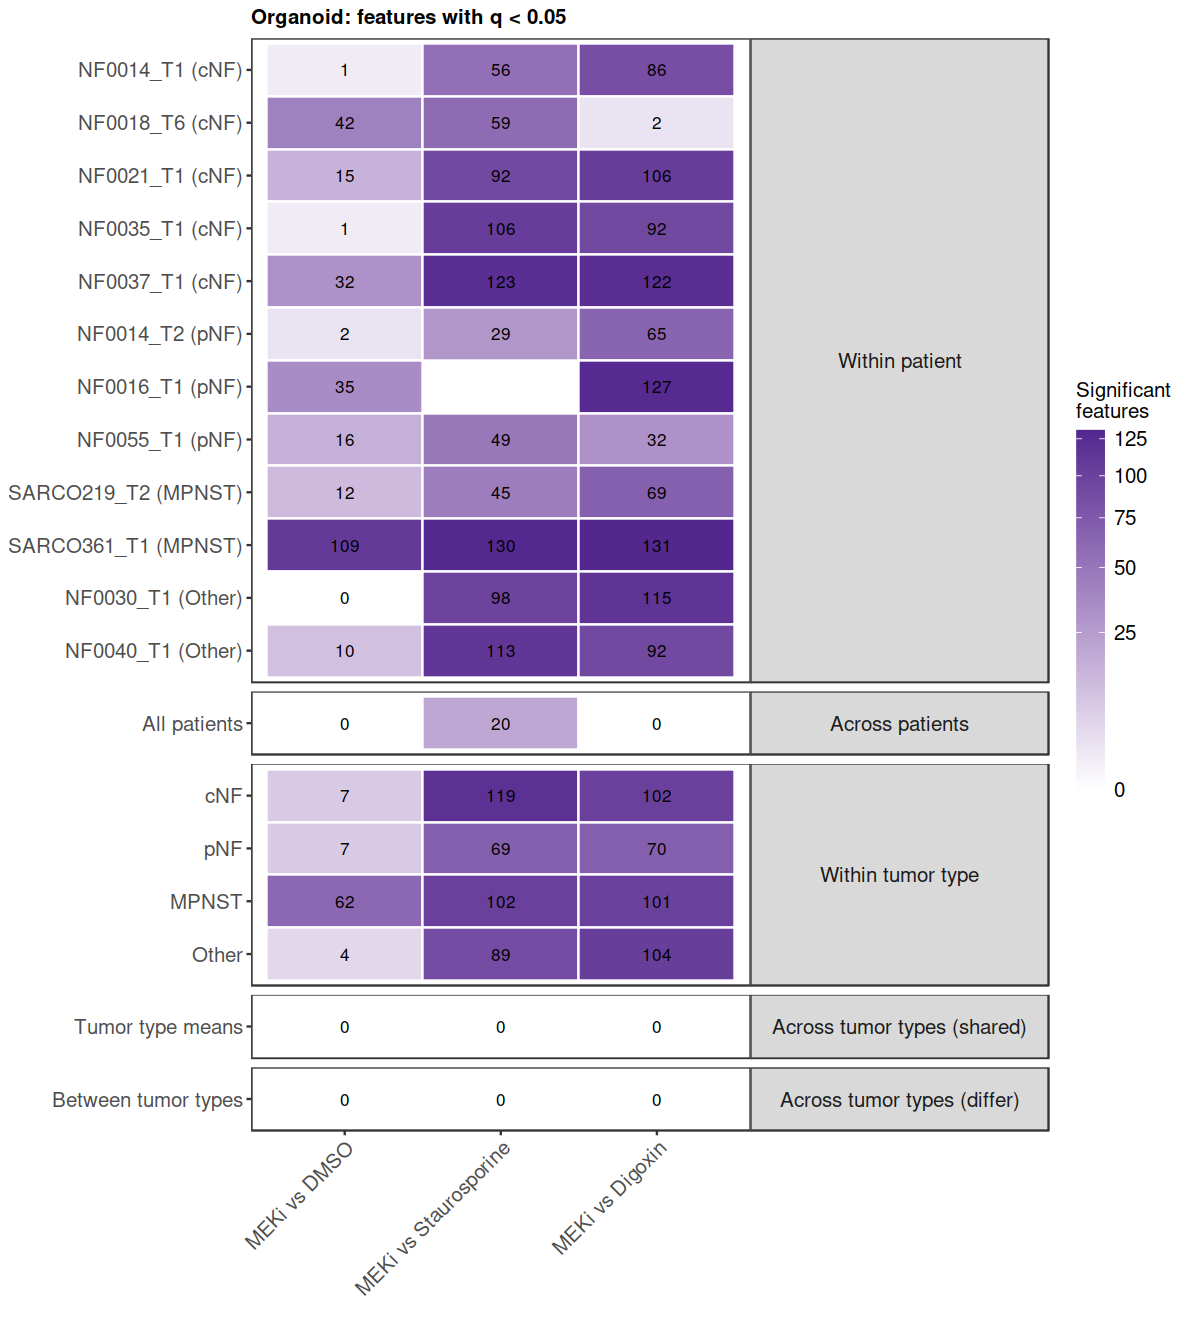

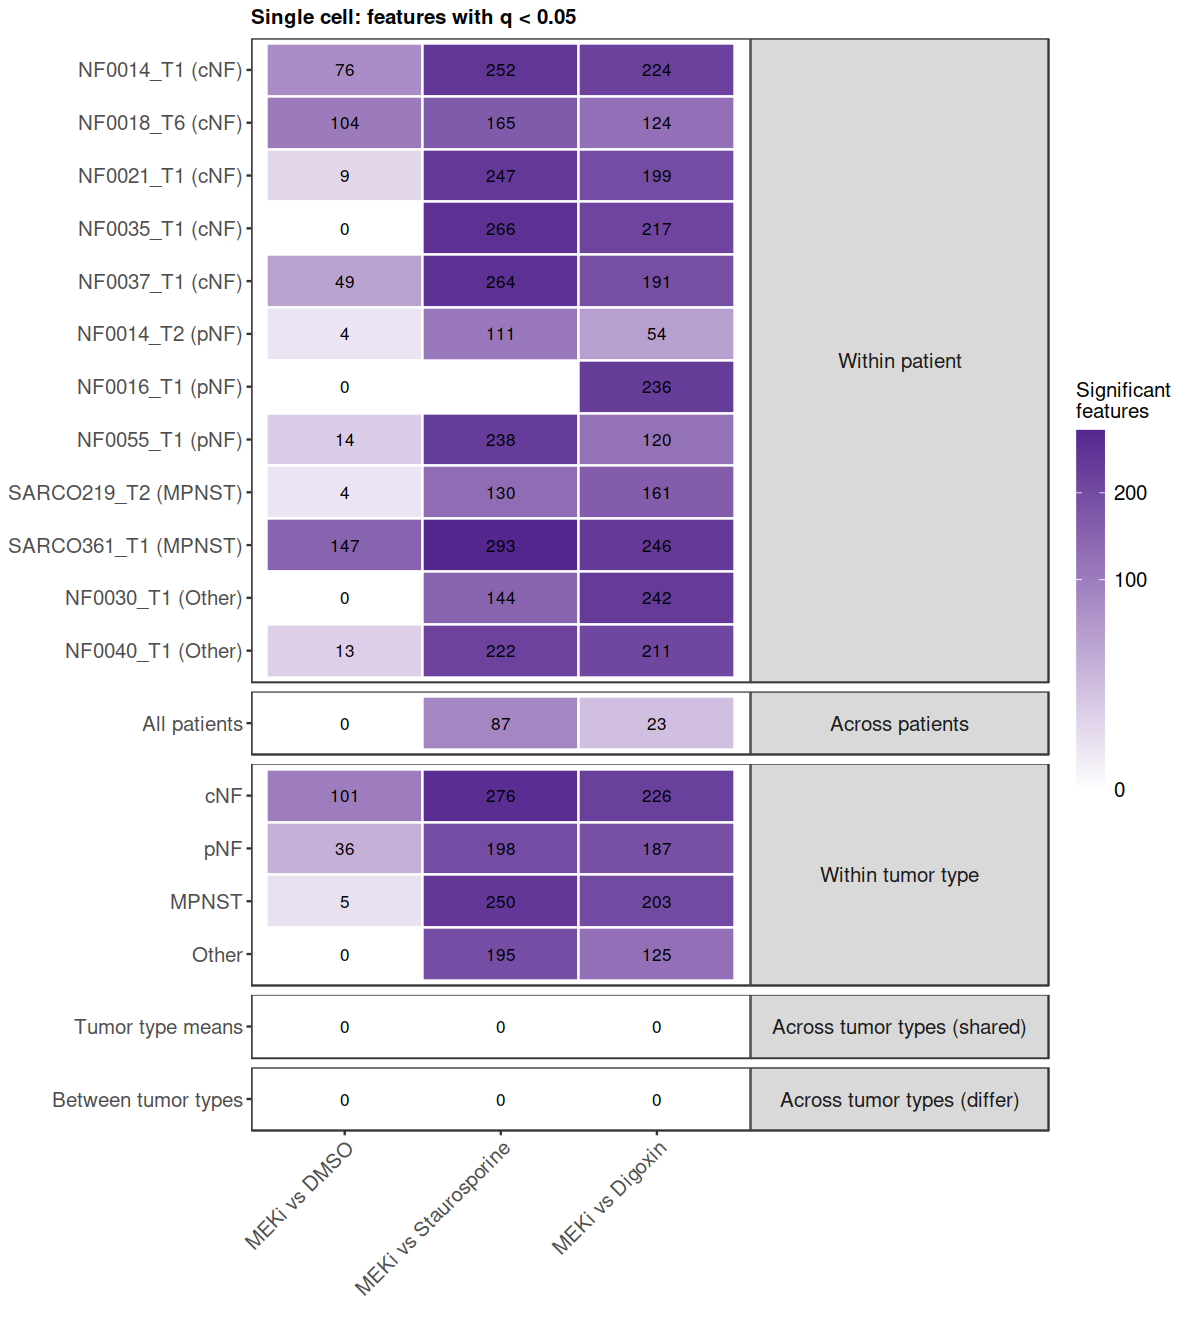

In [4]:
count_df <- level_test_df %>%
    group_by(compartment, level, group_label, contrast) %>%
    summarise(n_significant = sum(significant), .groups = "drop")

options(repr.plot.width = 10, repr.plot.height = 11)
count_plots <- lapply(levels(count_df$compartment), function(compartment_name) {
    (
        ggplot(
            count_df %>% filter(compartment == compartment_name),
            aes(x = contrast, y = group_label, fill = n_significant)
        )
        + geom_tile(color = "white", linewidth = 0.5)
        + geom_text(aes(label = n_significant), size = 3.5)
        + scale_fill_gradient(
            low = "white",
            high = "#54278f",
            trans = "sqrt",
            guide = guide_colourbar(barheight = unit(3, "in"))
        )
        + scale_y_discrete(limits = rev)
        + facet_grid(level ~ ., scales = "free_y", space = "free_y")
        + labs(
            title = paste0(compartment_name, ": features with q < ", Q_THRESHOLD),
            x = NULL,
            y = NULL,
            fill = "Significant\nfeatures"
        )
        + theme_manuscript(base_size = 12, x_text = "angled")
        + theme(panel.grid = element_blank(), strip.text.y = element_text(angle = 0))
    )
})
for (count_plot in count_plots) print(count_plot)

### Which contrasts share significant features (UpSet)
Sets are the contrasts (MEKi vs DMSO / Staurosporine / Digoxin). Each bar counts the elements that are significant under exactly the contrasts marked below it: features for the pooled levels, patient x feature pairs for within patient, and tumor type x feature pairs for within tumor type.
The significant feature count tiles and these UpSet pages are saved together to `mek_significant_feature_counts.pdf`.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggupset package.
  Please report the issue at <https://github.com/const-ae/ggupset/issues>.”
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


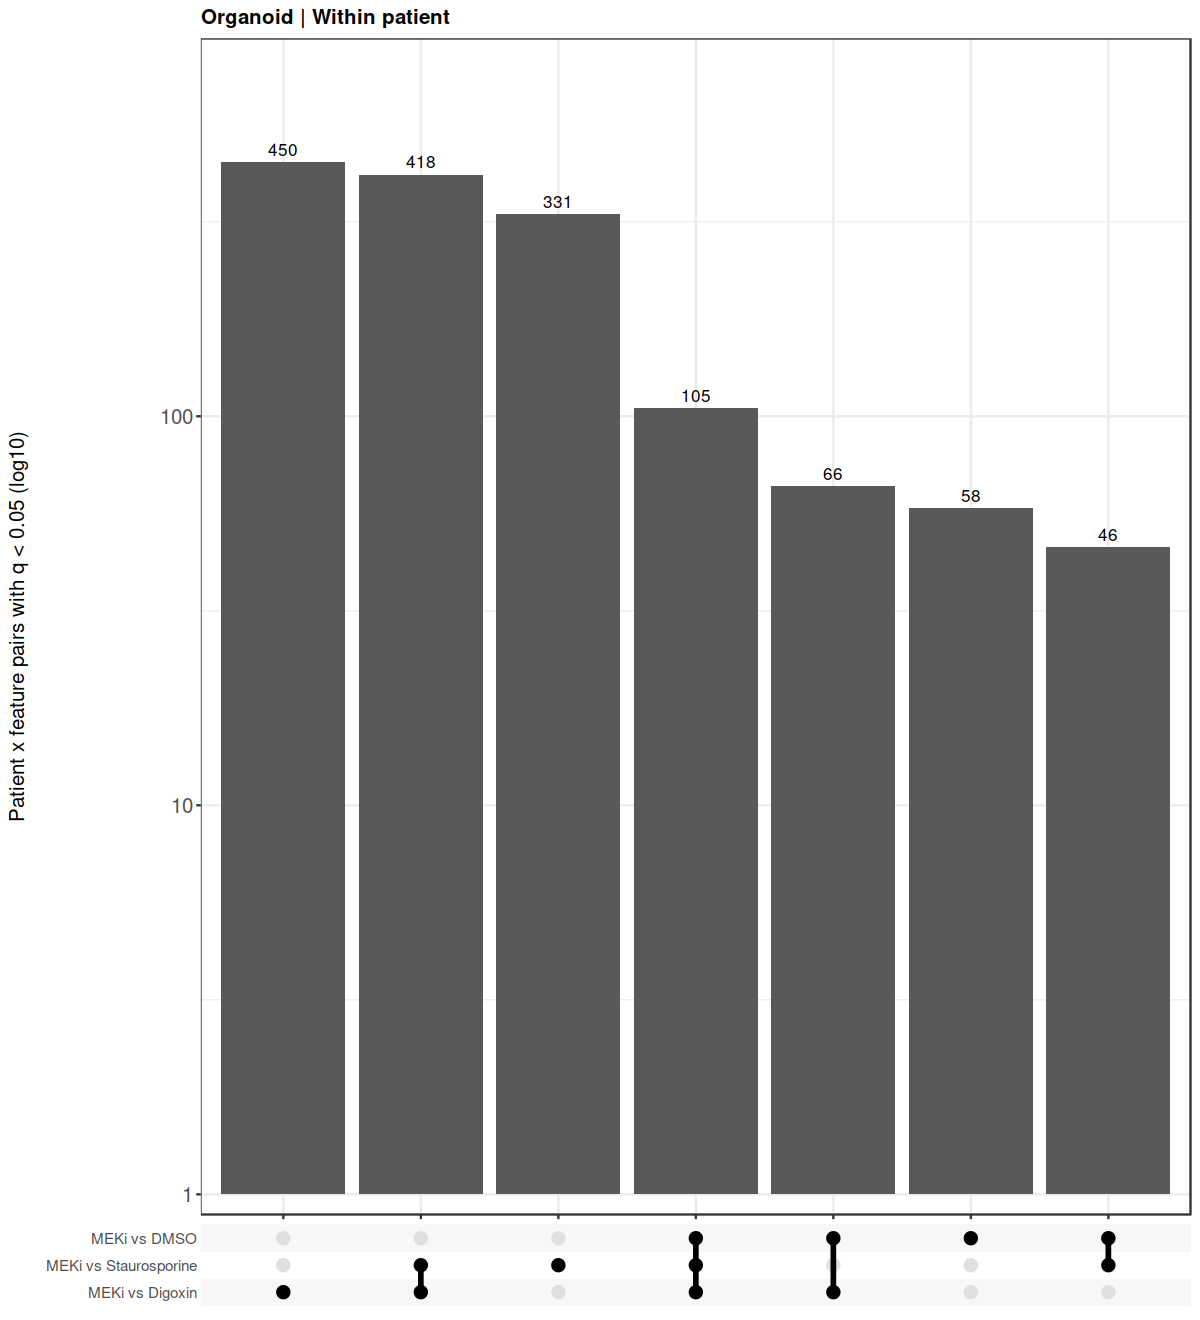

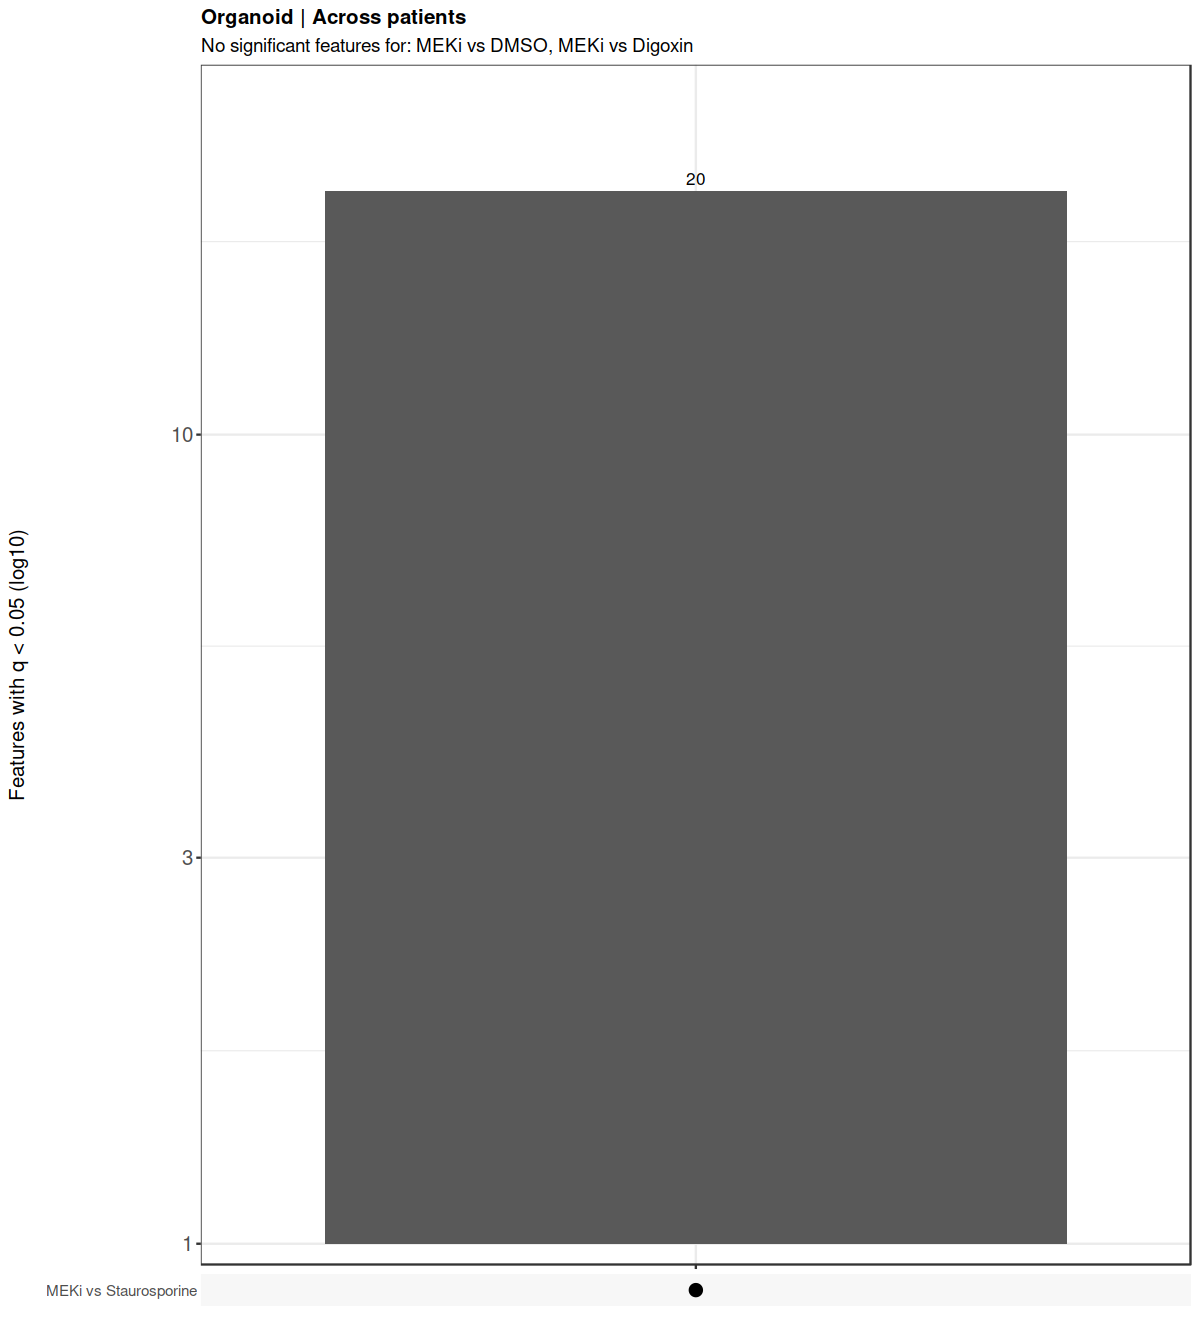

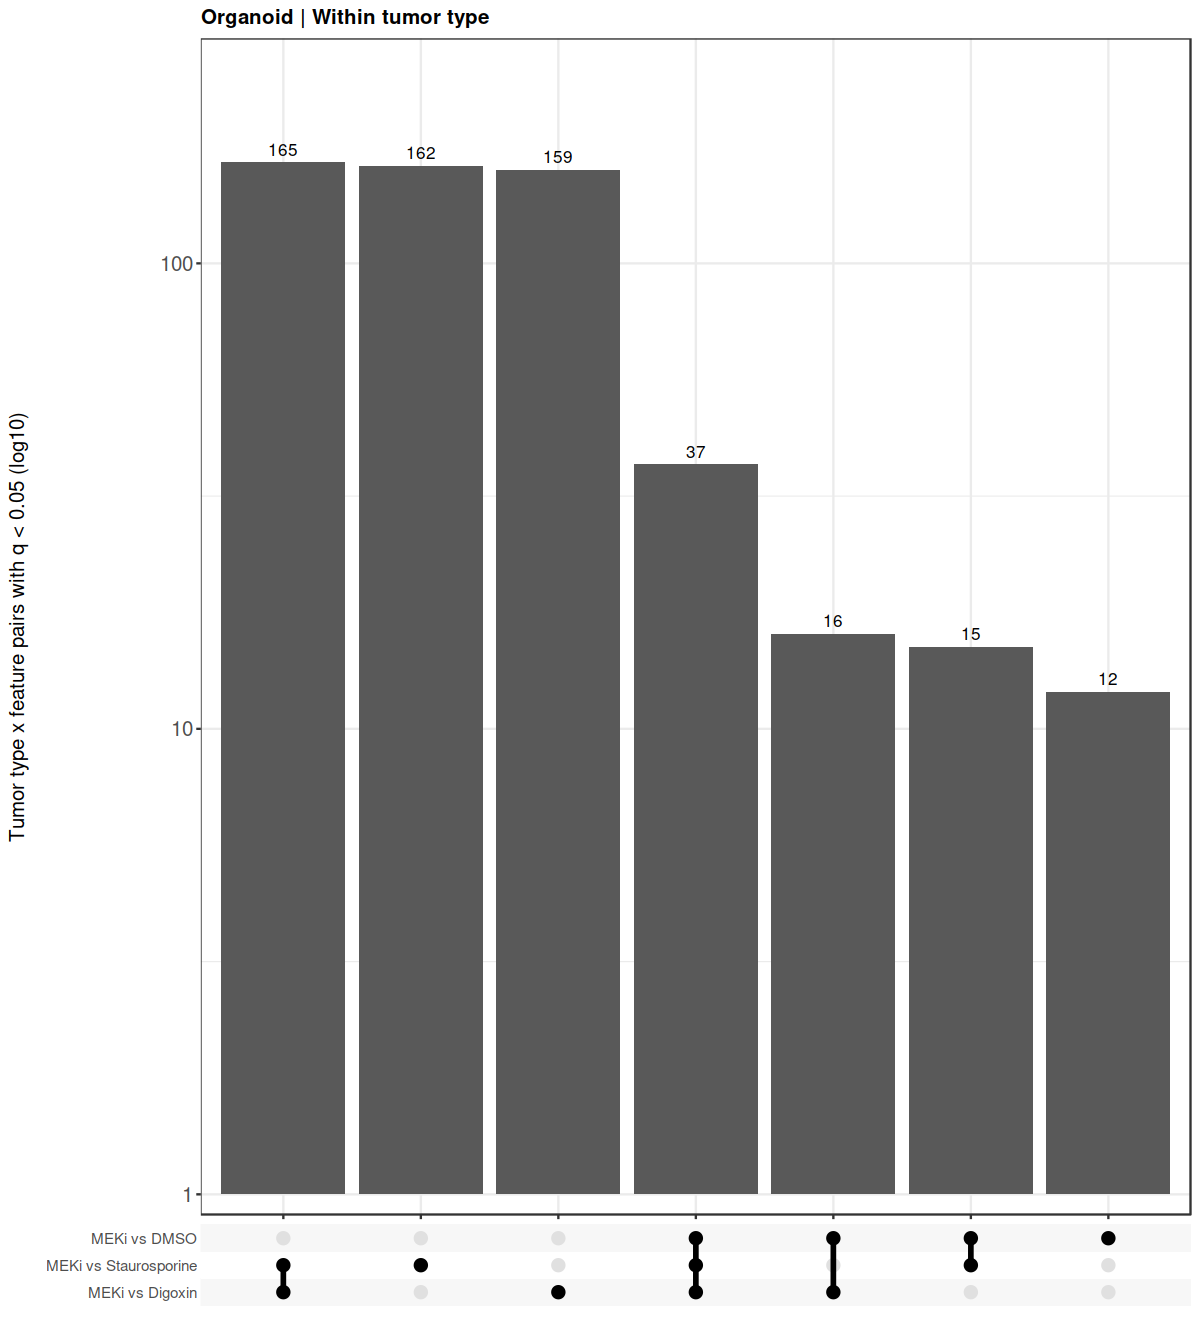

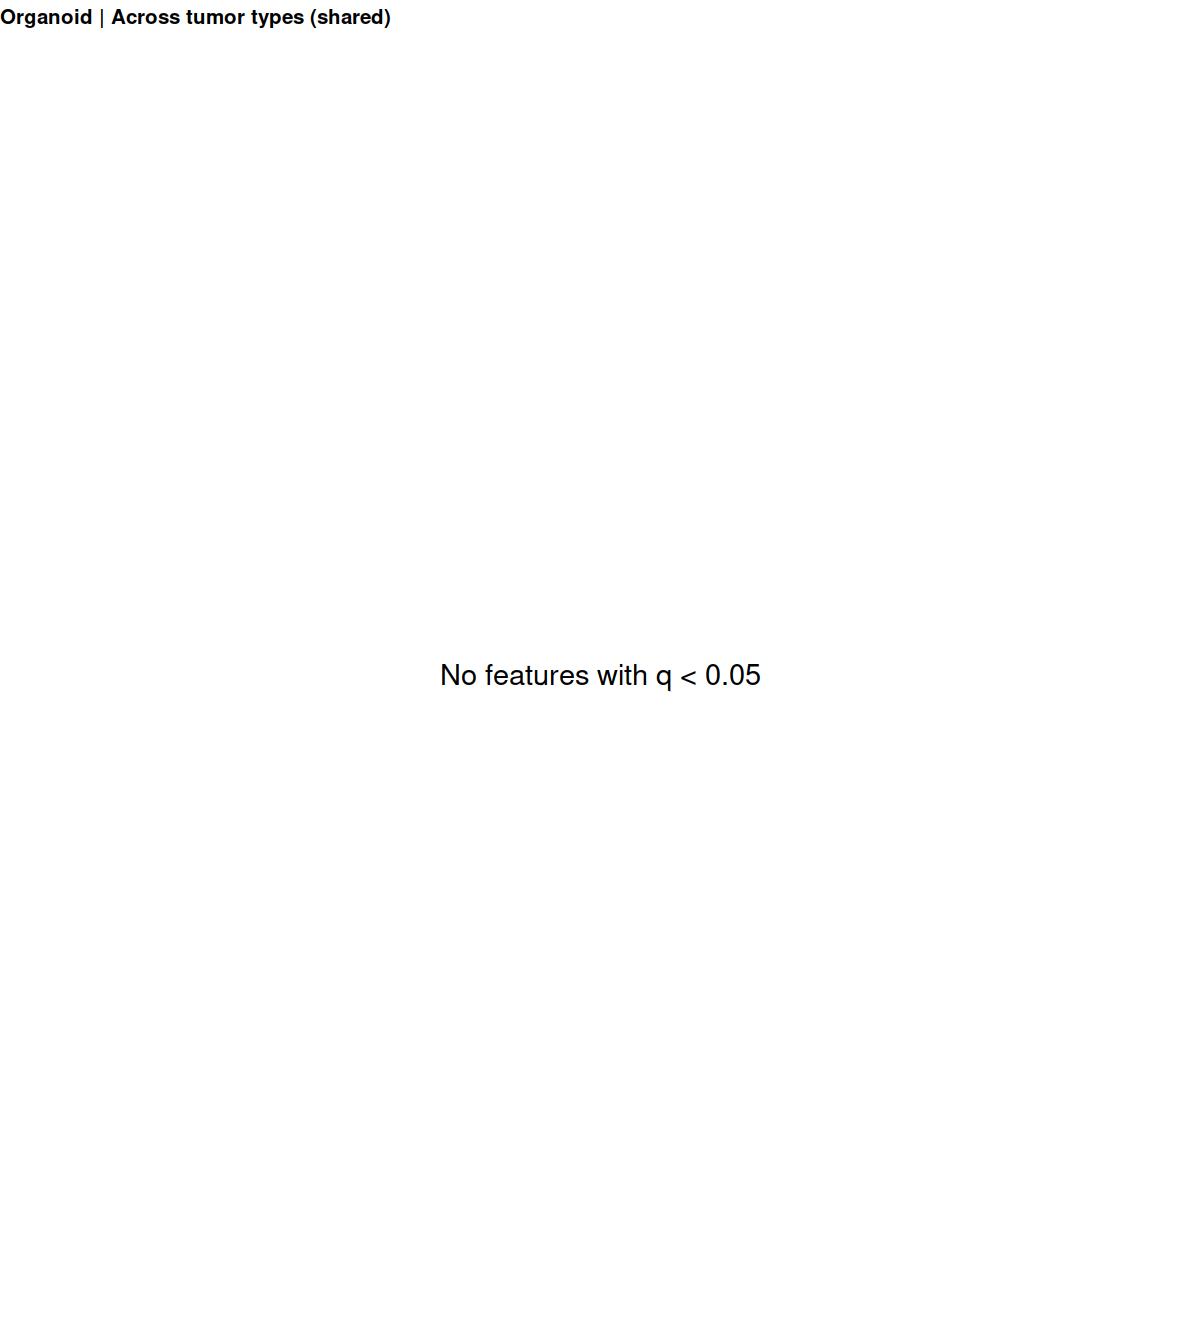

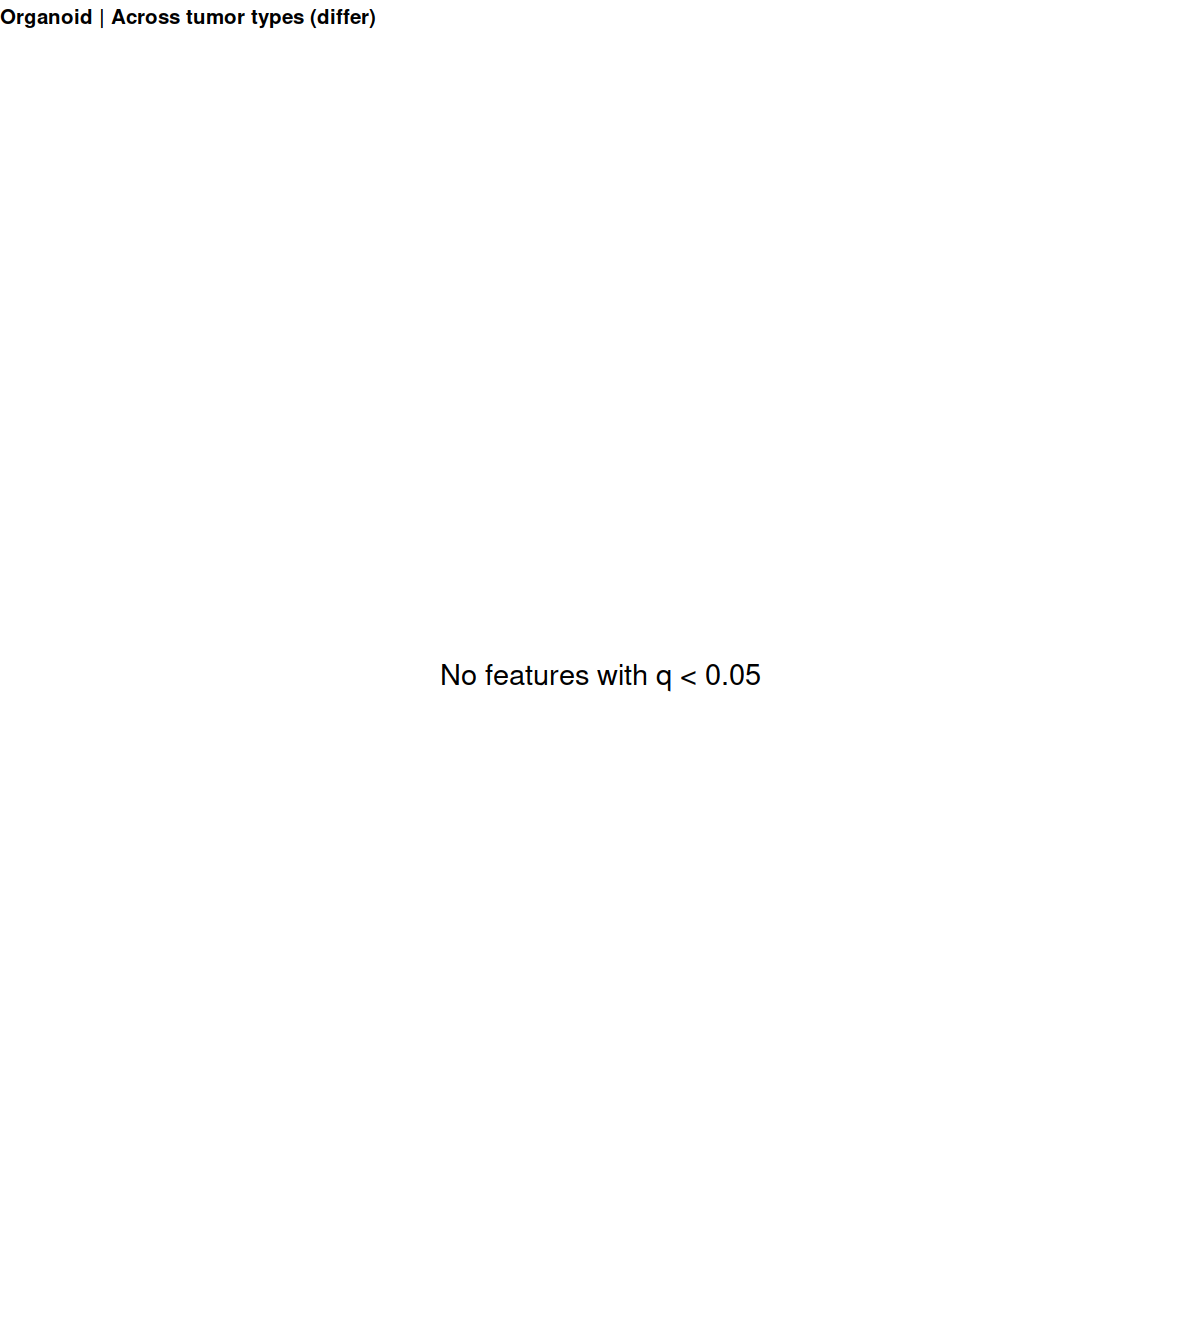

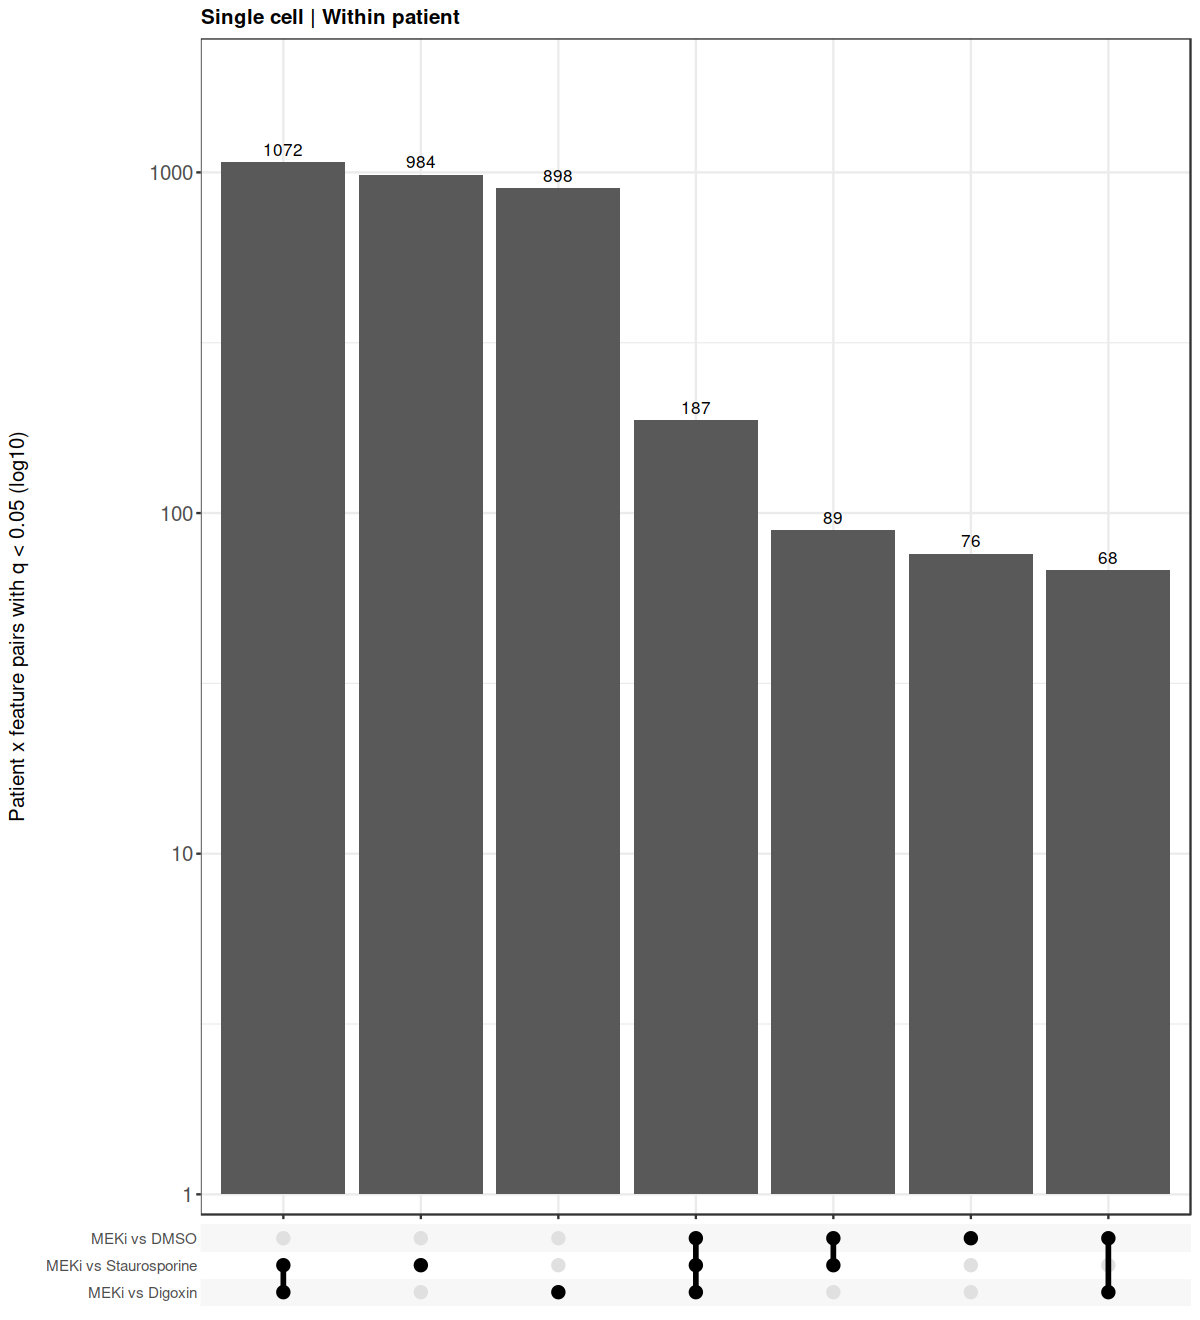

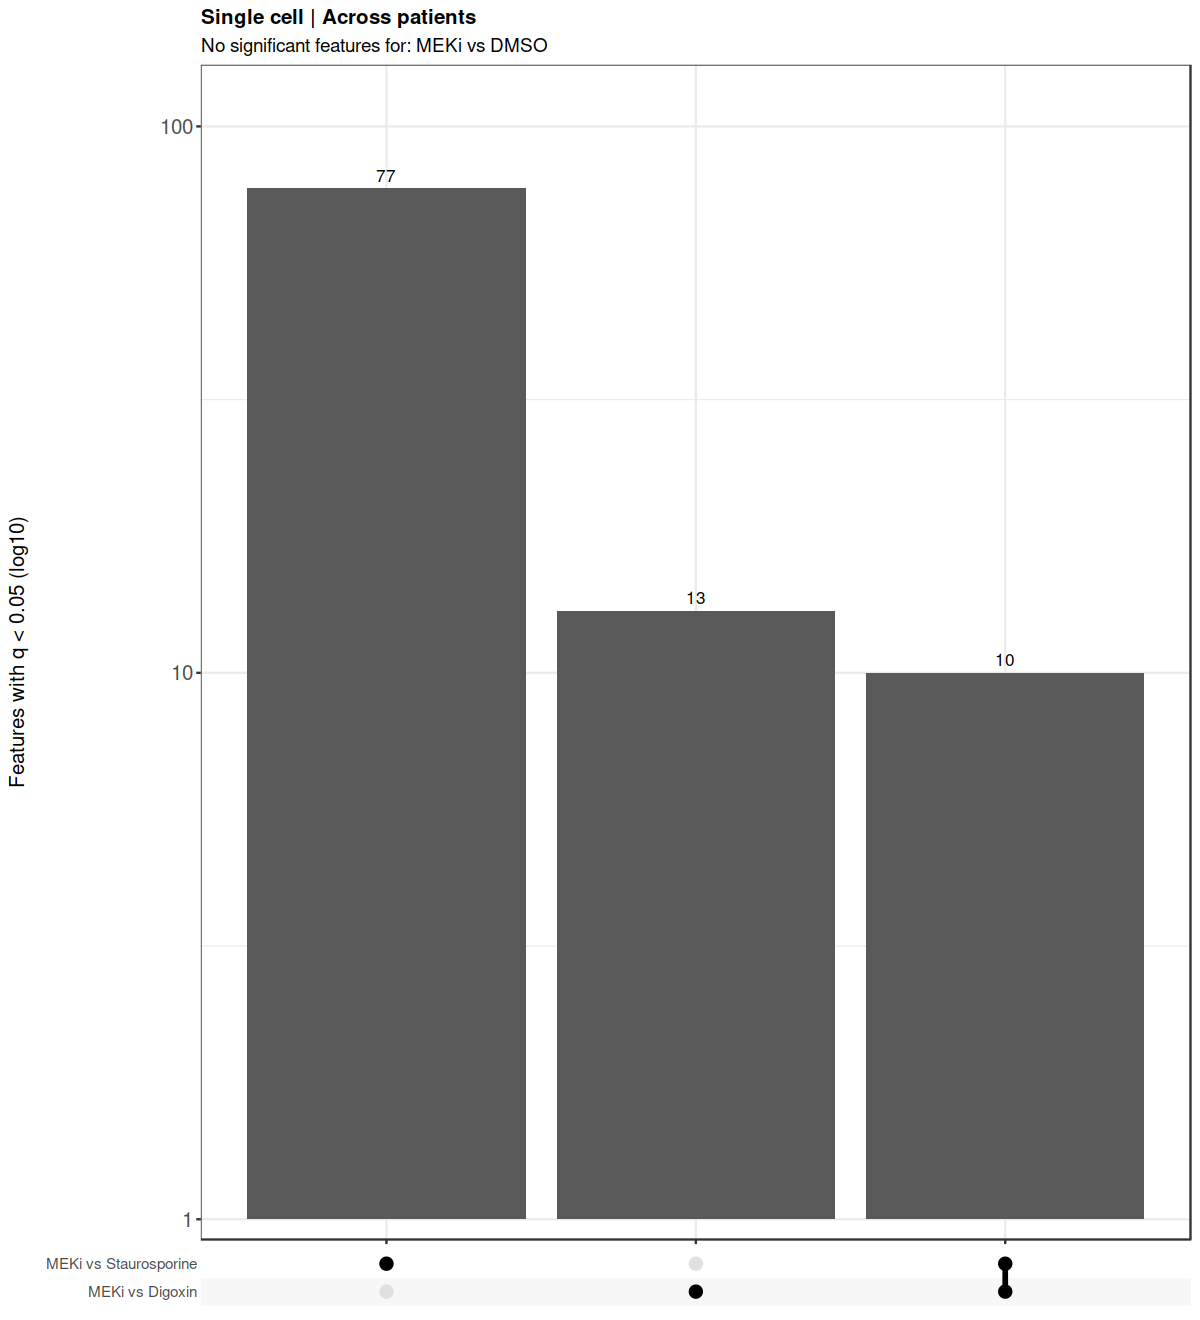

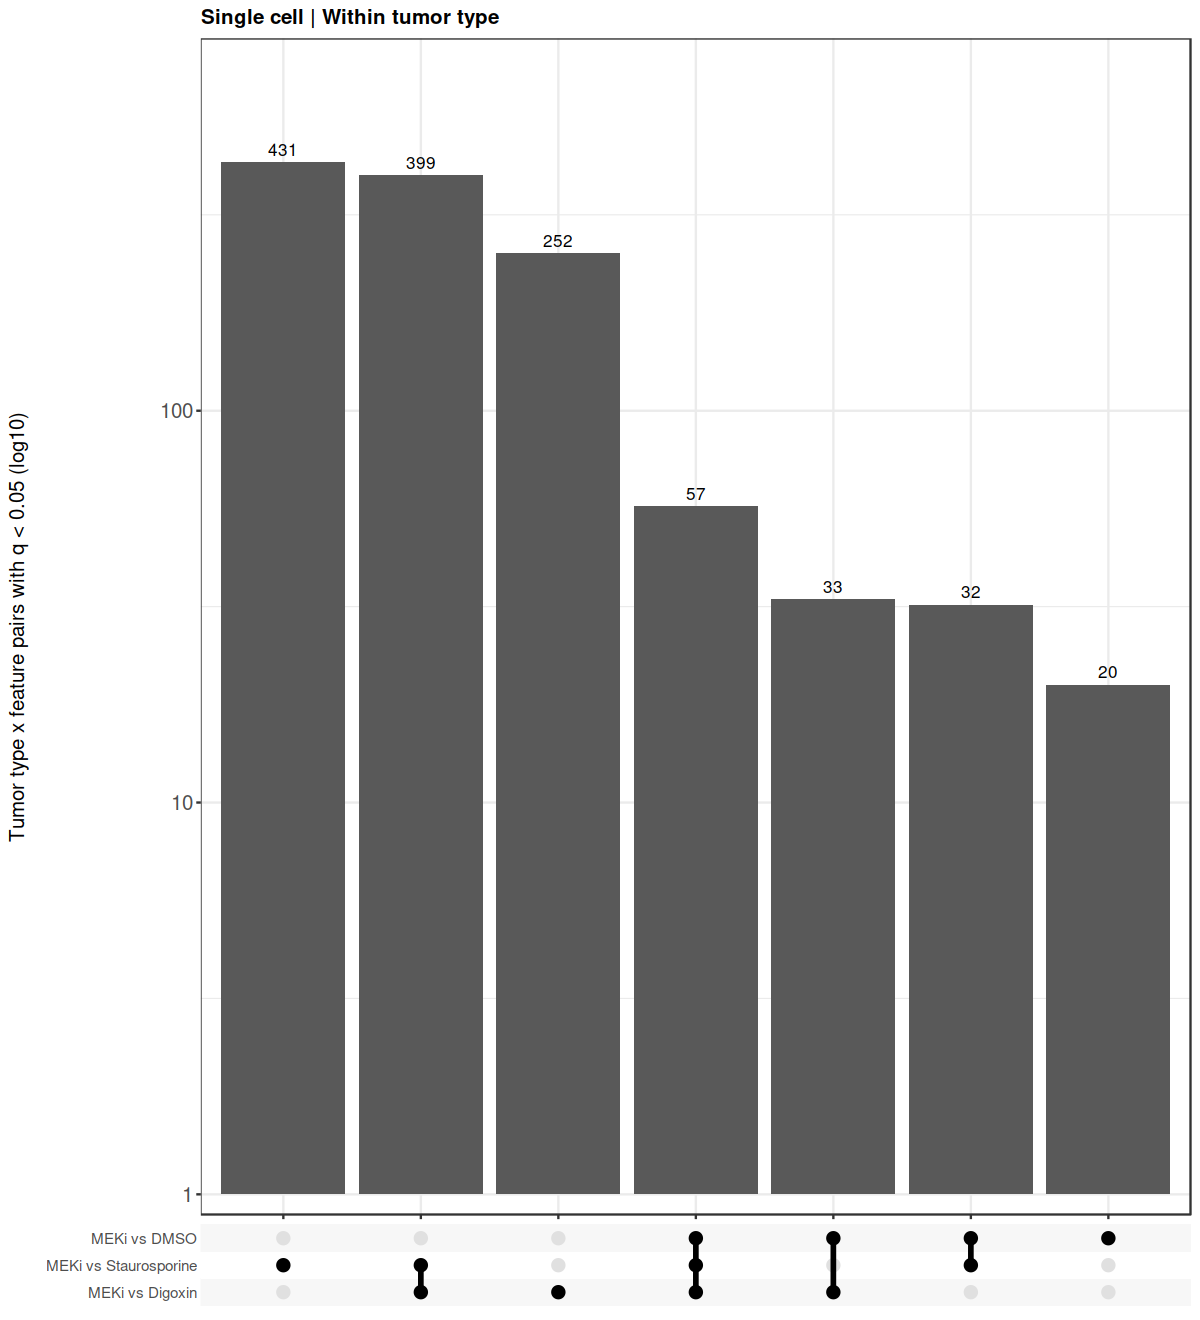

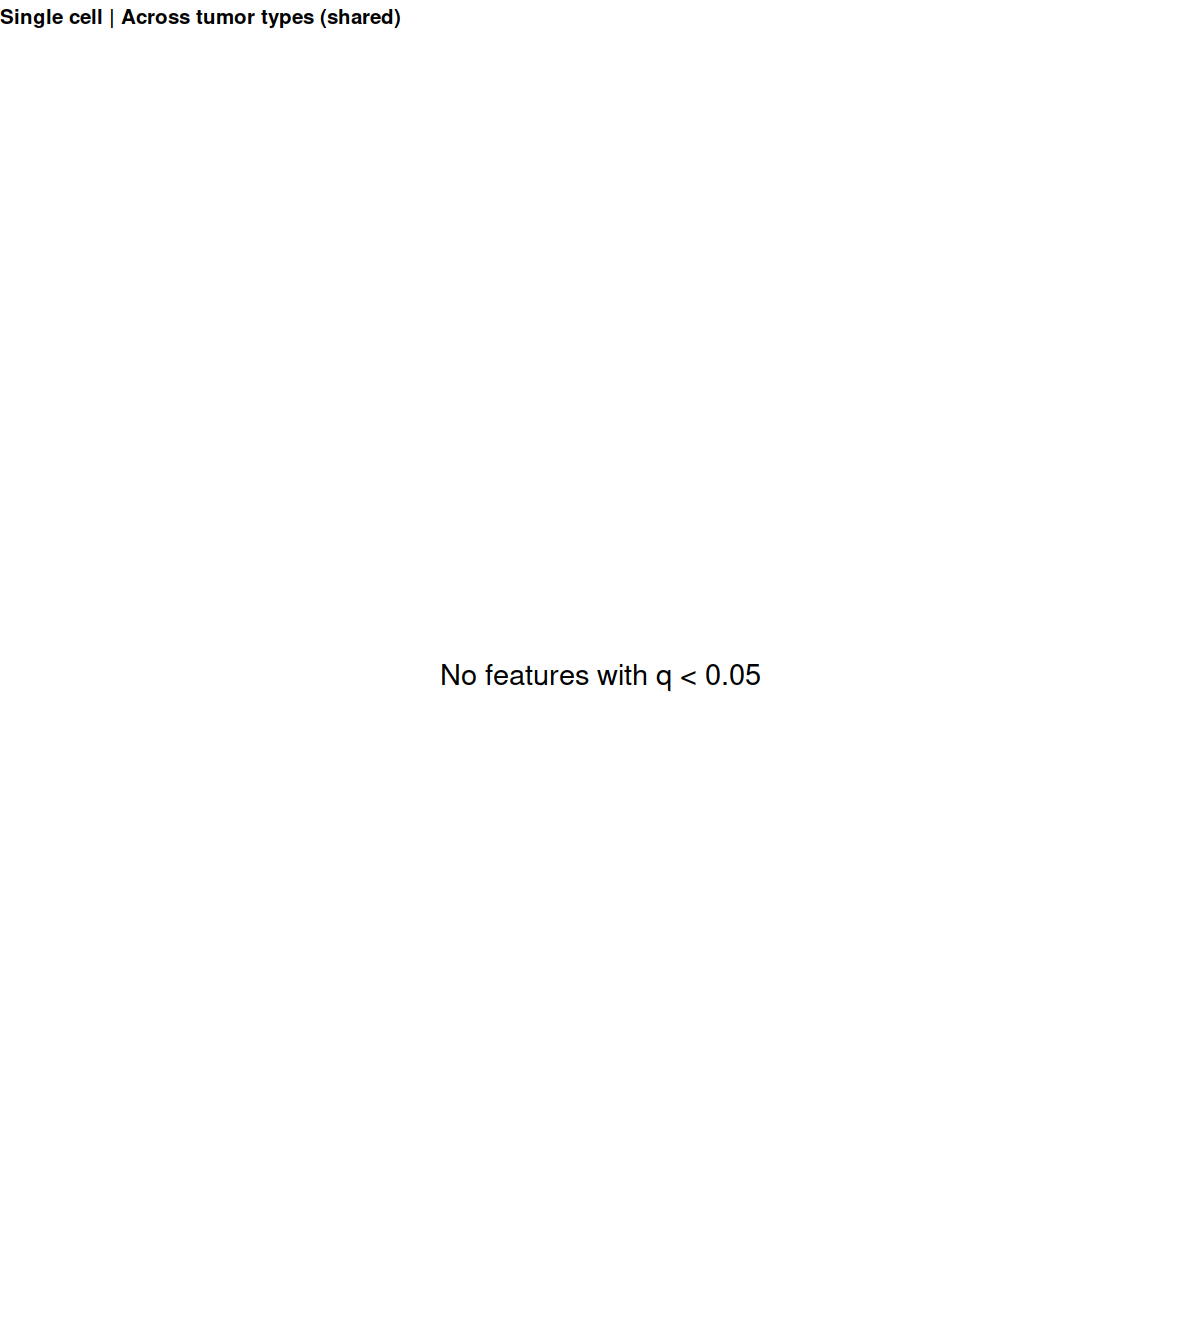

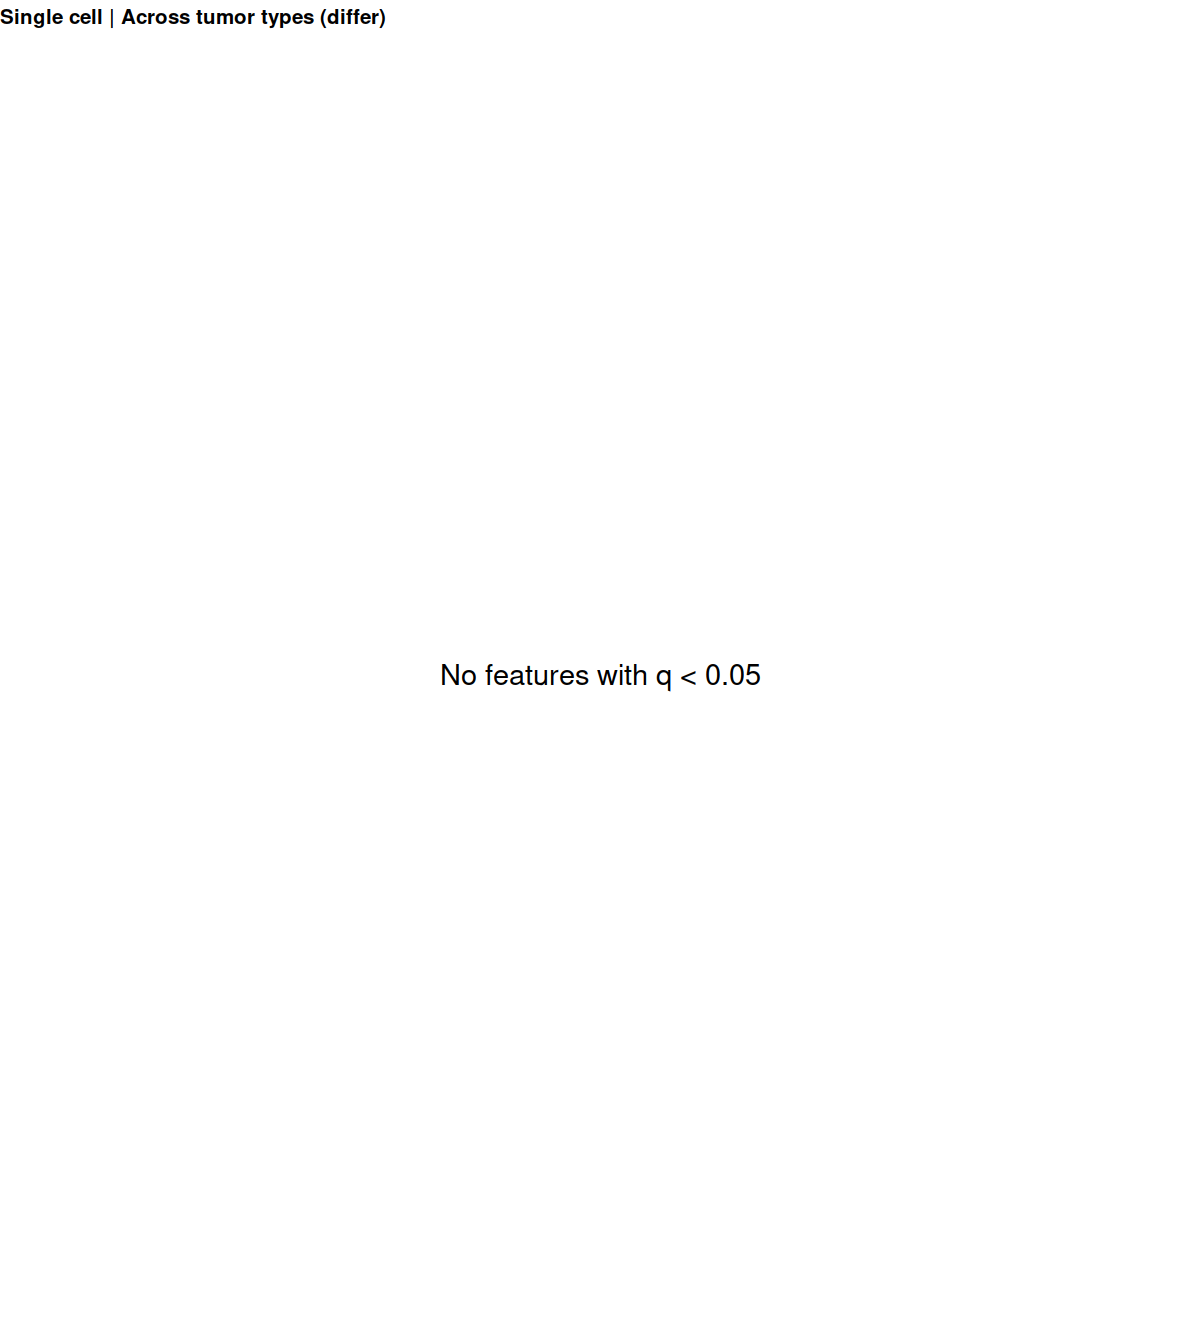

In [5]:
# each element is a significant feature, or a feature in one patient / tumor type for the within levels;
# the sets are the contrasts (treatments), so each bar counts the elements shared by exactly that combination
upset_df <- level_test_df %>%
    filter(significant) %>%
    mutate(element = if_else(group == "all", feature, paste(group, feature, sep = " | "))) %>%
    group_by(compartment, level, element) %>%
    summarise(contrasts = list(sort(unique(as.character(contrast)))), .groups = "drop")

upset_plot <- function(compartment_name, level_name) {
    plot_df <- upset_df %>% filter(compartment == compartment_name, level == level_name)
    title <- paste0(compartment_name, " | ", level_name)
    if (nrow(plot_df) == 0) {
        return(
            ggplot()
            + annotate("text", x = 0, y = 0, label = paste0("No features with q < ", Q_THRESHOLD), size = 6)
            + labs(title = title)
            + theme_manuscript_void(base_size = 12)
        )
    }
    unit_label <- case_when(
        level_name == level_labels[["within_patient"]] ~ "Patient x feature pairs",
        level_name == level_labels[["within_tumor_type"]] ~ "Tumor type x feature pairs",
        TRUE ~ "Features"
    )
    missing_sets <- setdiff(contrast_levels, unlist(plot_df$contrasts))
    subtitle <- if (length(missing_sets) > 0) {
        paste0("No significant features for: ", paste(missing_sets, collapse = ", "))
    } else {
        NULL
    }
    (
        ggplot(plot_df, aes(x = contrasts))
        + geom_bar()
        + scale_y_log10(expand = expansion(mult = c(0.02, 0.12)))
        + geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5, size = 3.5)
        + scale_x_upset(sets = contrast_levels)
        + labs(title = title, subtitle = subtitle, x = NULL, y = paste0(unit_label, " with q < ", Q_THRESHOLD, " (log10)"))
        + theme_manuscript(base_size = 12)
    )
}

upset_pages <- expand.grid(
    level = levels(level_test_df$level),
    compartment = levels(level_test_df$compartment),
    stringsAsFactors = FALSE
)
upset_plots <- mapply(upset_plot, upset_pages$compartment, upset_pages$level, SIMPLIFY = FALSE)
save_plots_pdf(
    c(count_plots, upset_plots),
    significant_count_path,
    width = 10,
    height = c(rep(11, length(count_plots)), rep(4, length(upset_plots)))
)
for (upset_page in upset_plots) print(upset_page)

## 2. Feature categories among significant features (q < 0.05)
One page per compartment x level, with all three contrasts (including MEKi vs DMSO) as columns.
Pooled levels are split by feature object; within-patient and within-tumor-type levels are split by patient / tumor type.

Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warnin

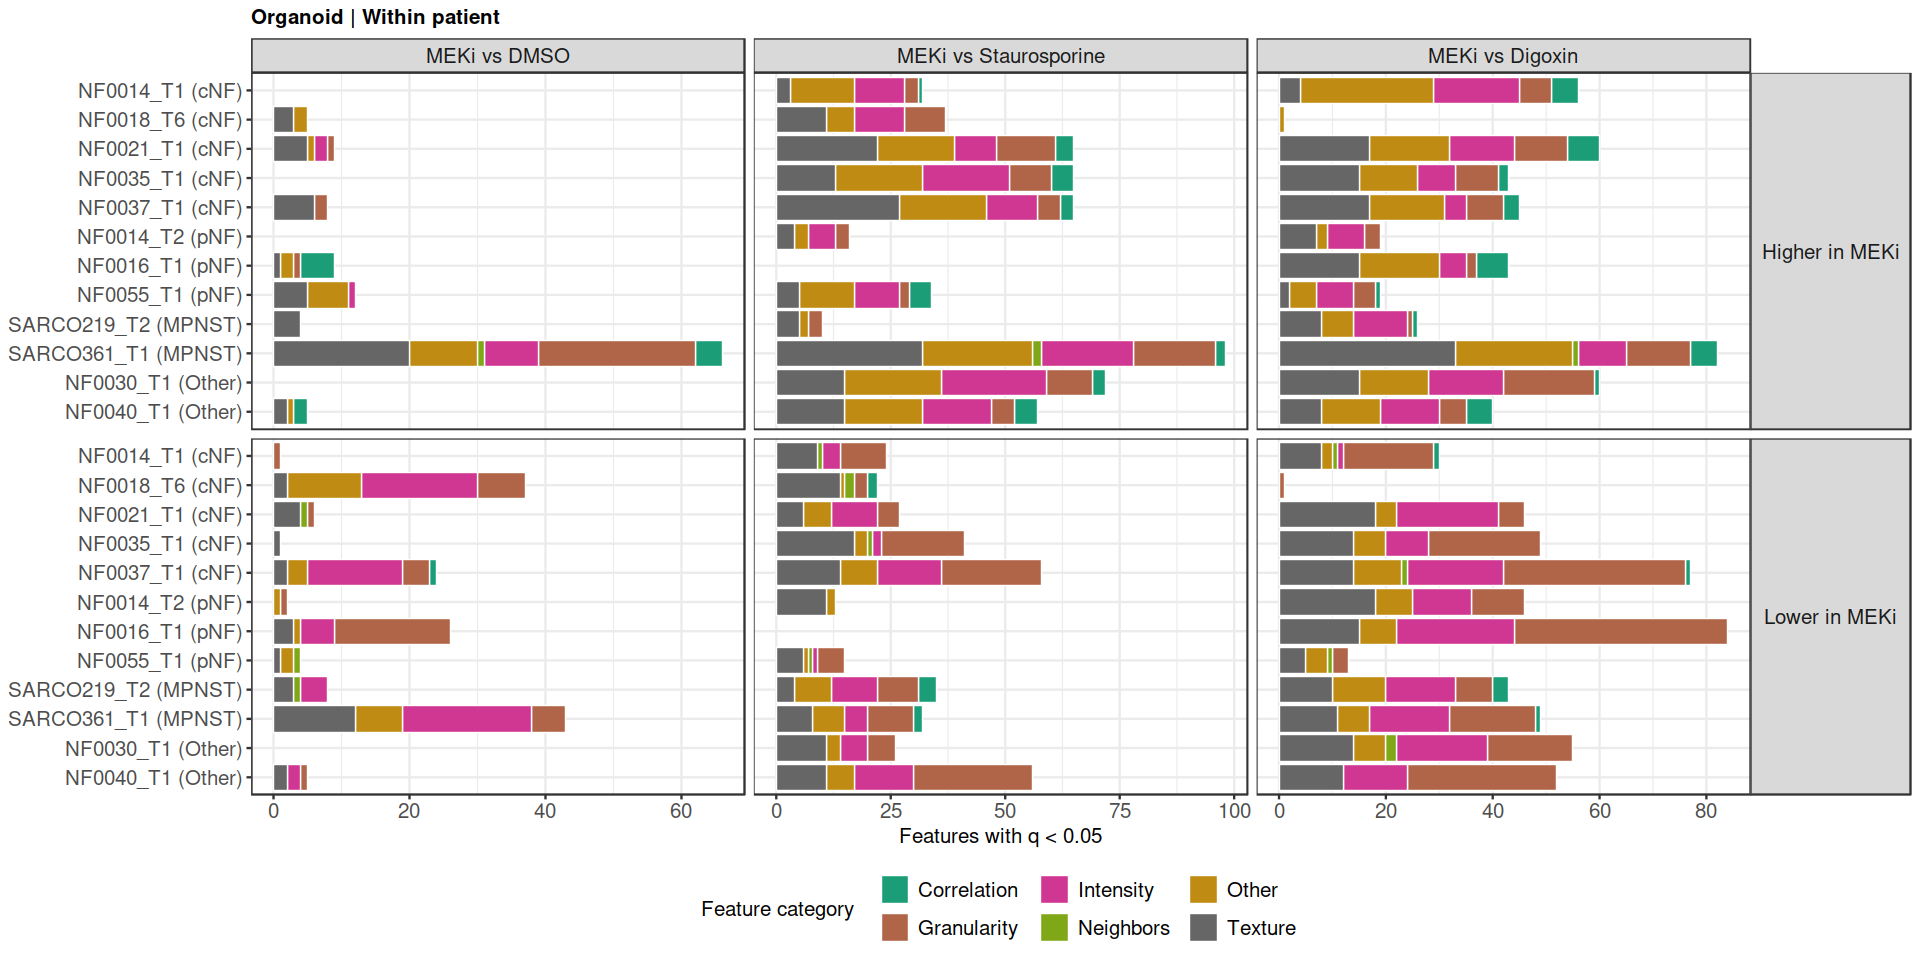

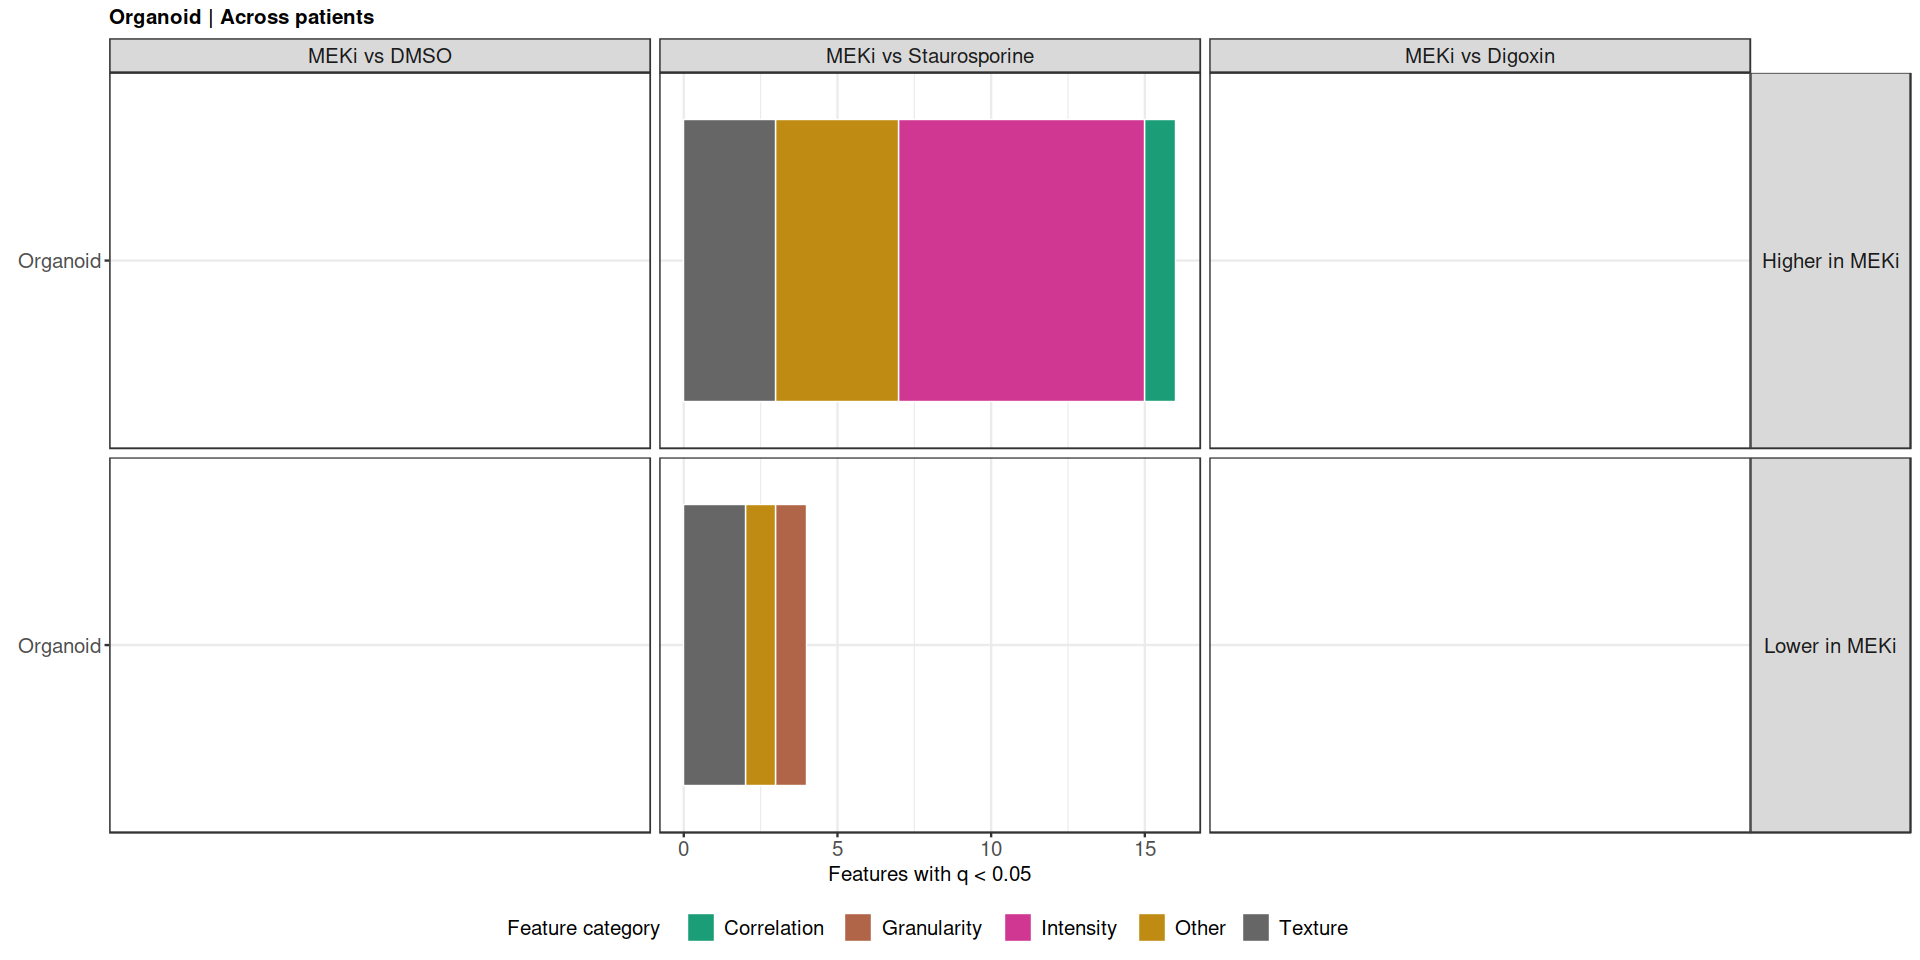

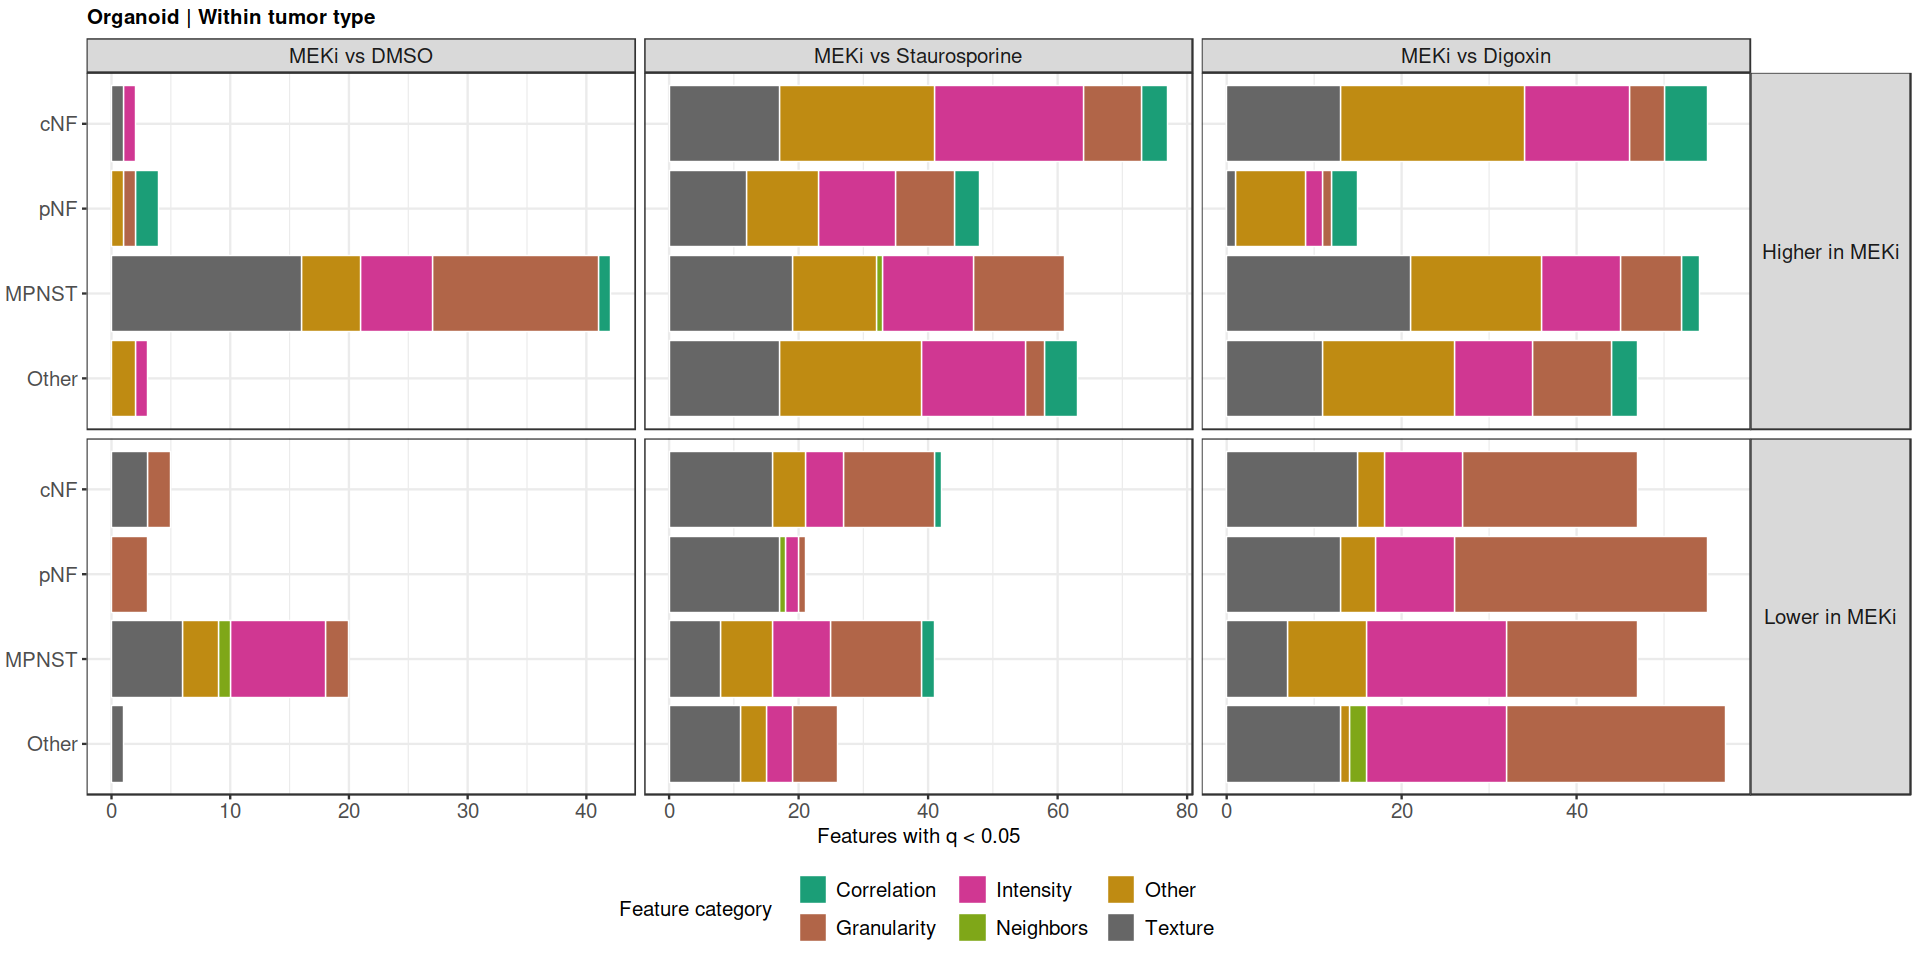

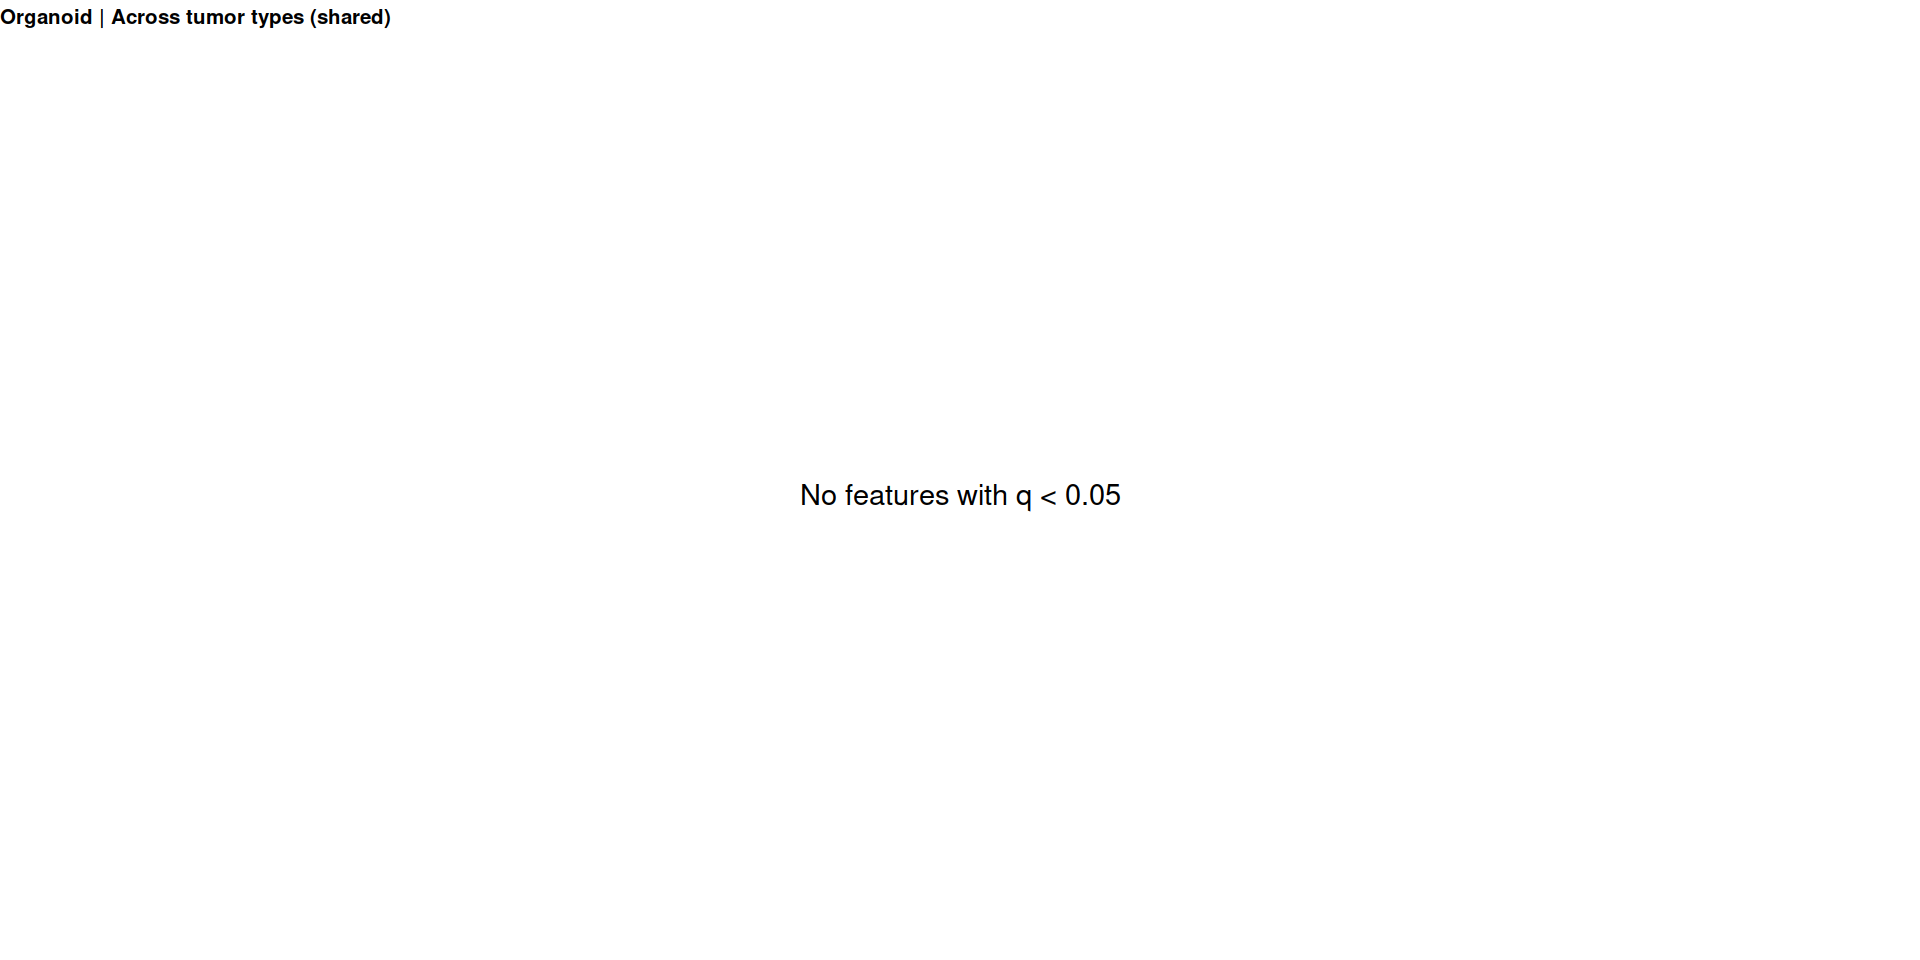

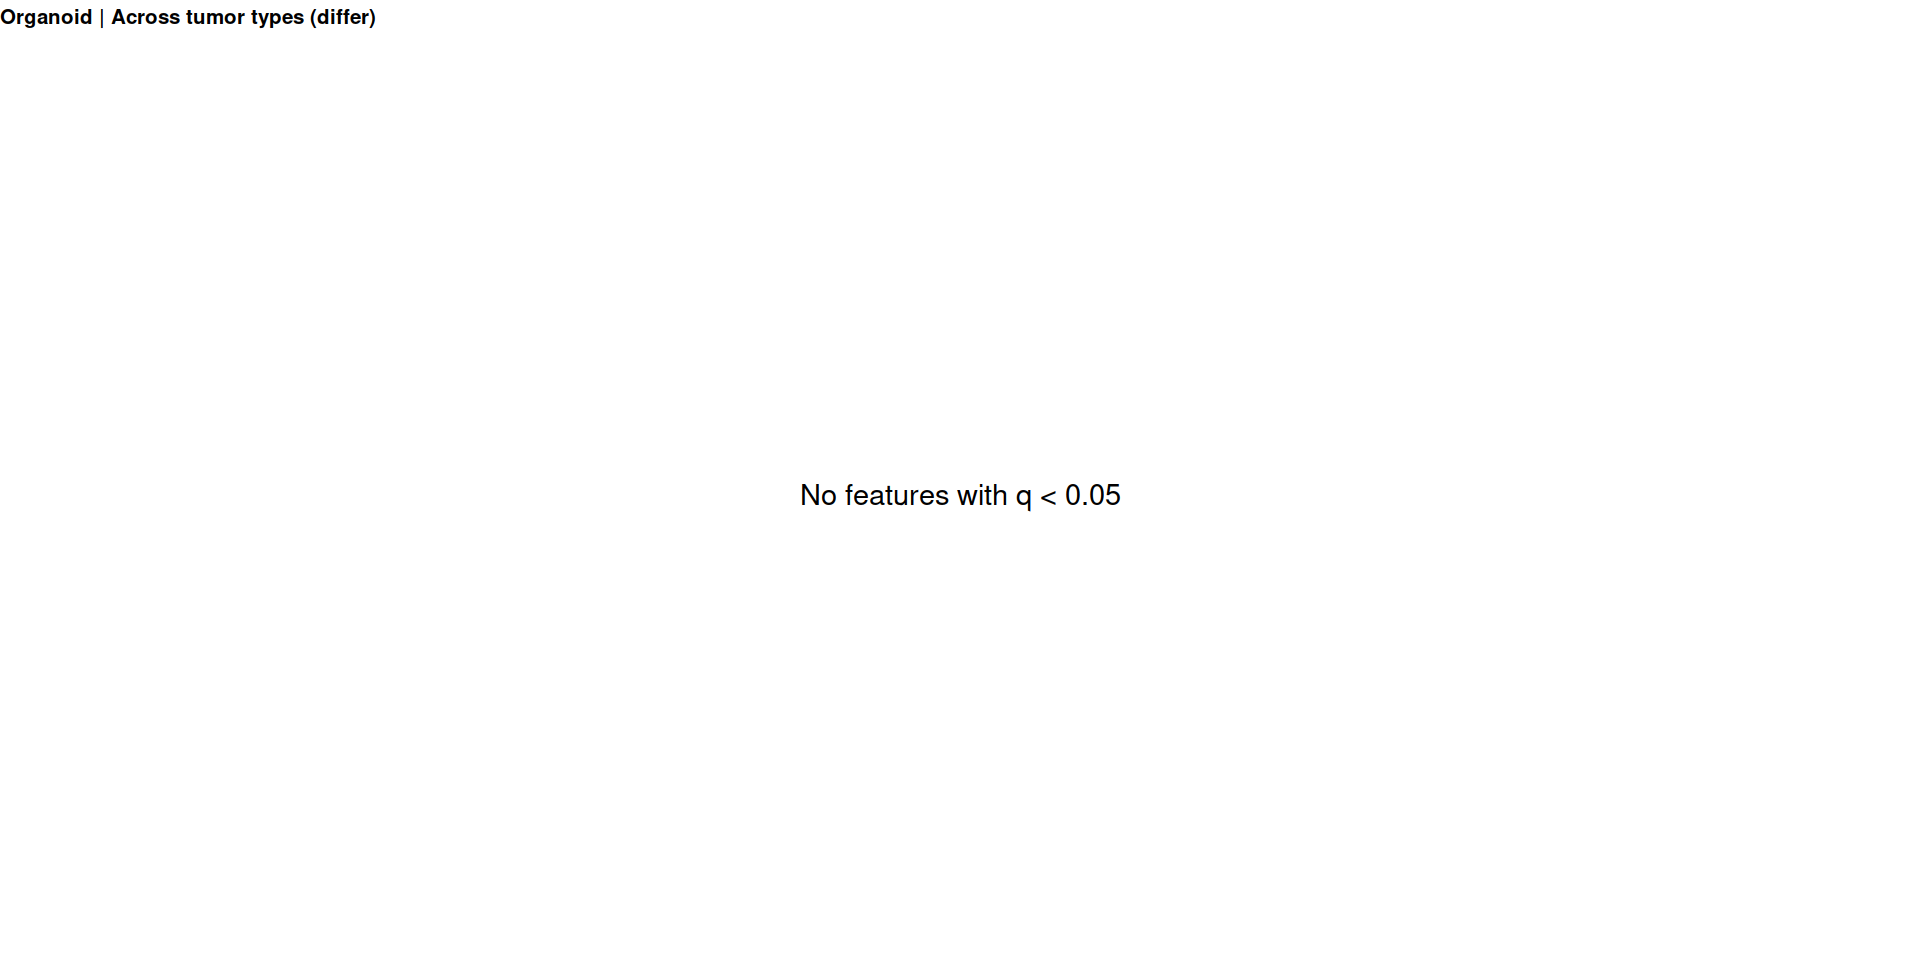

Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”


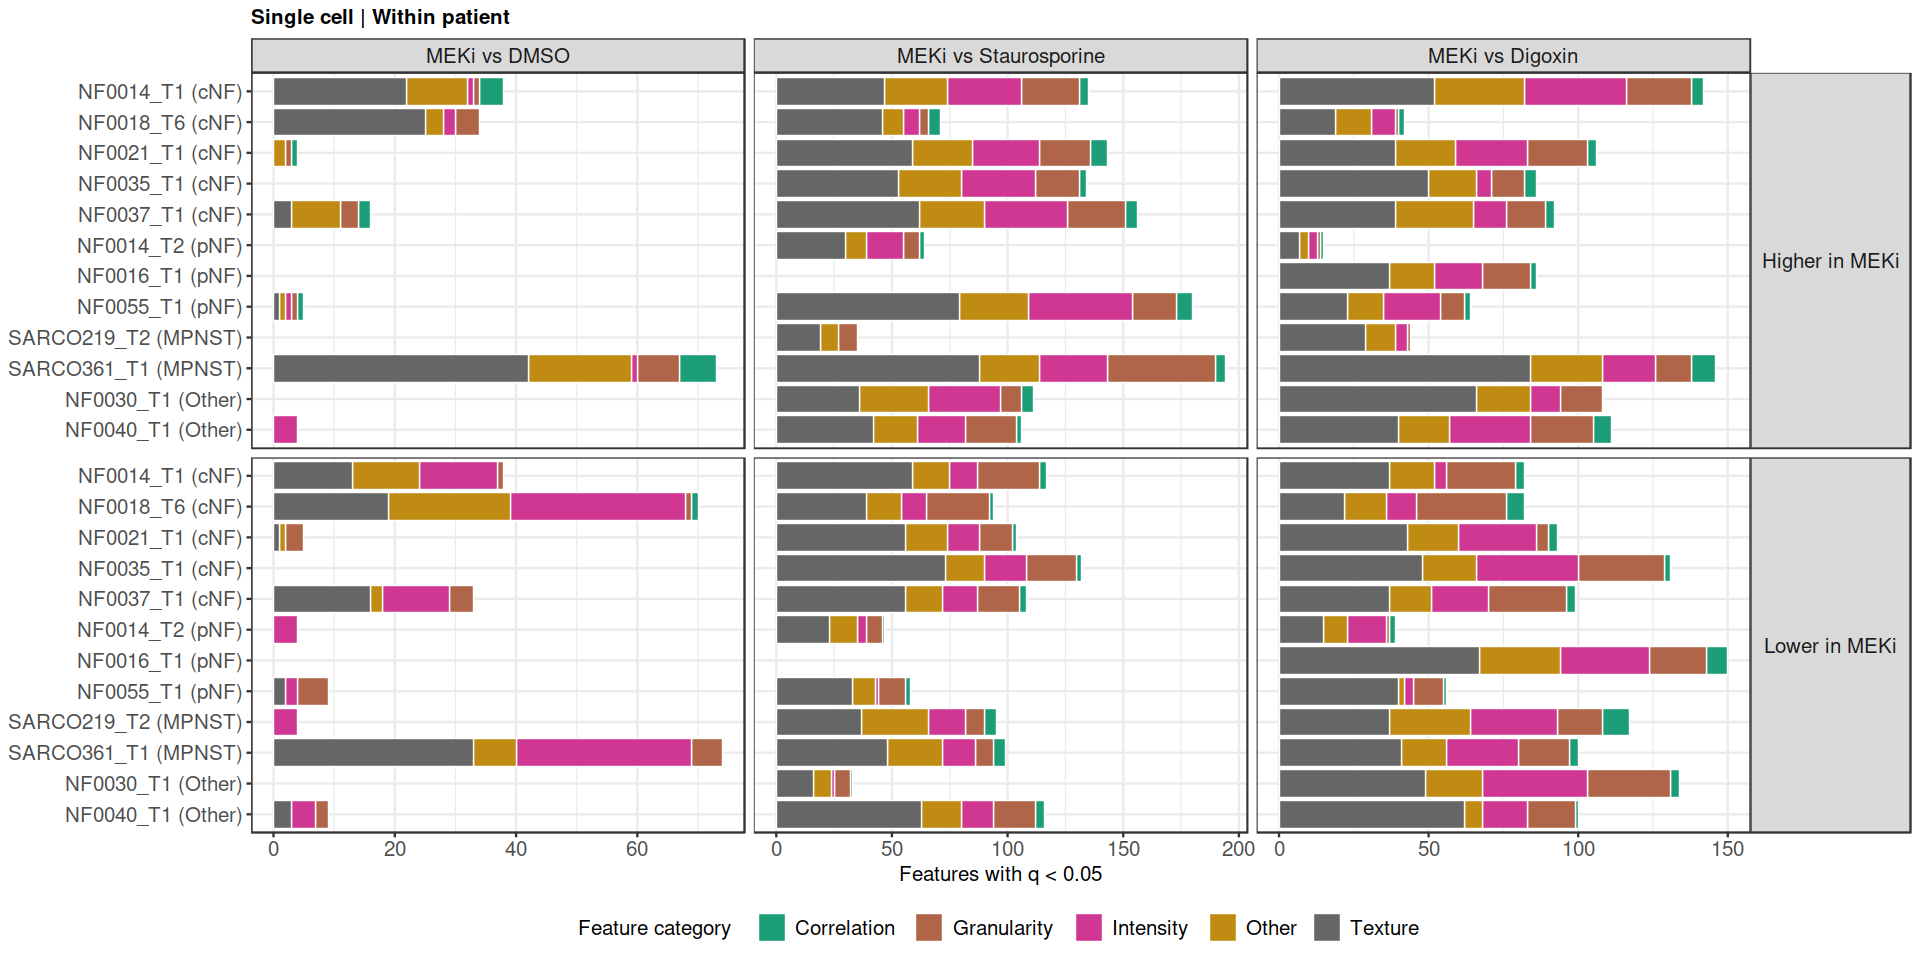

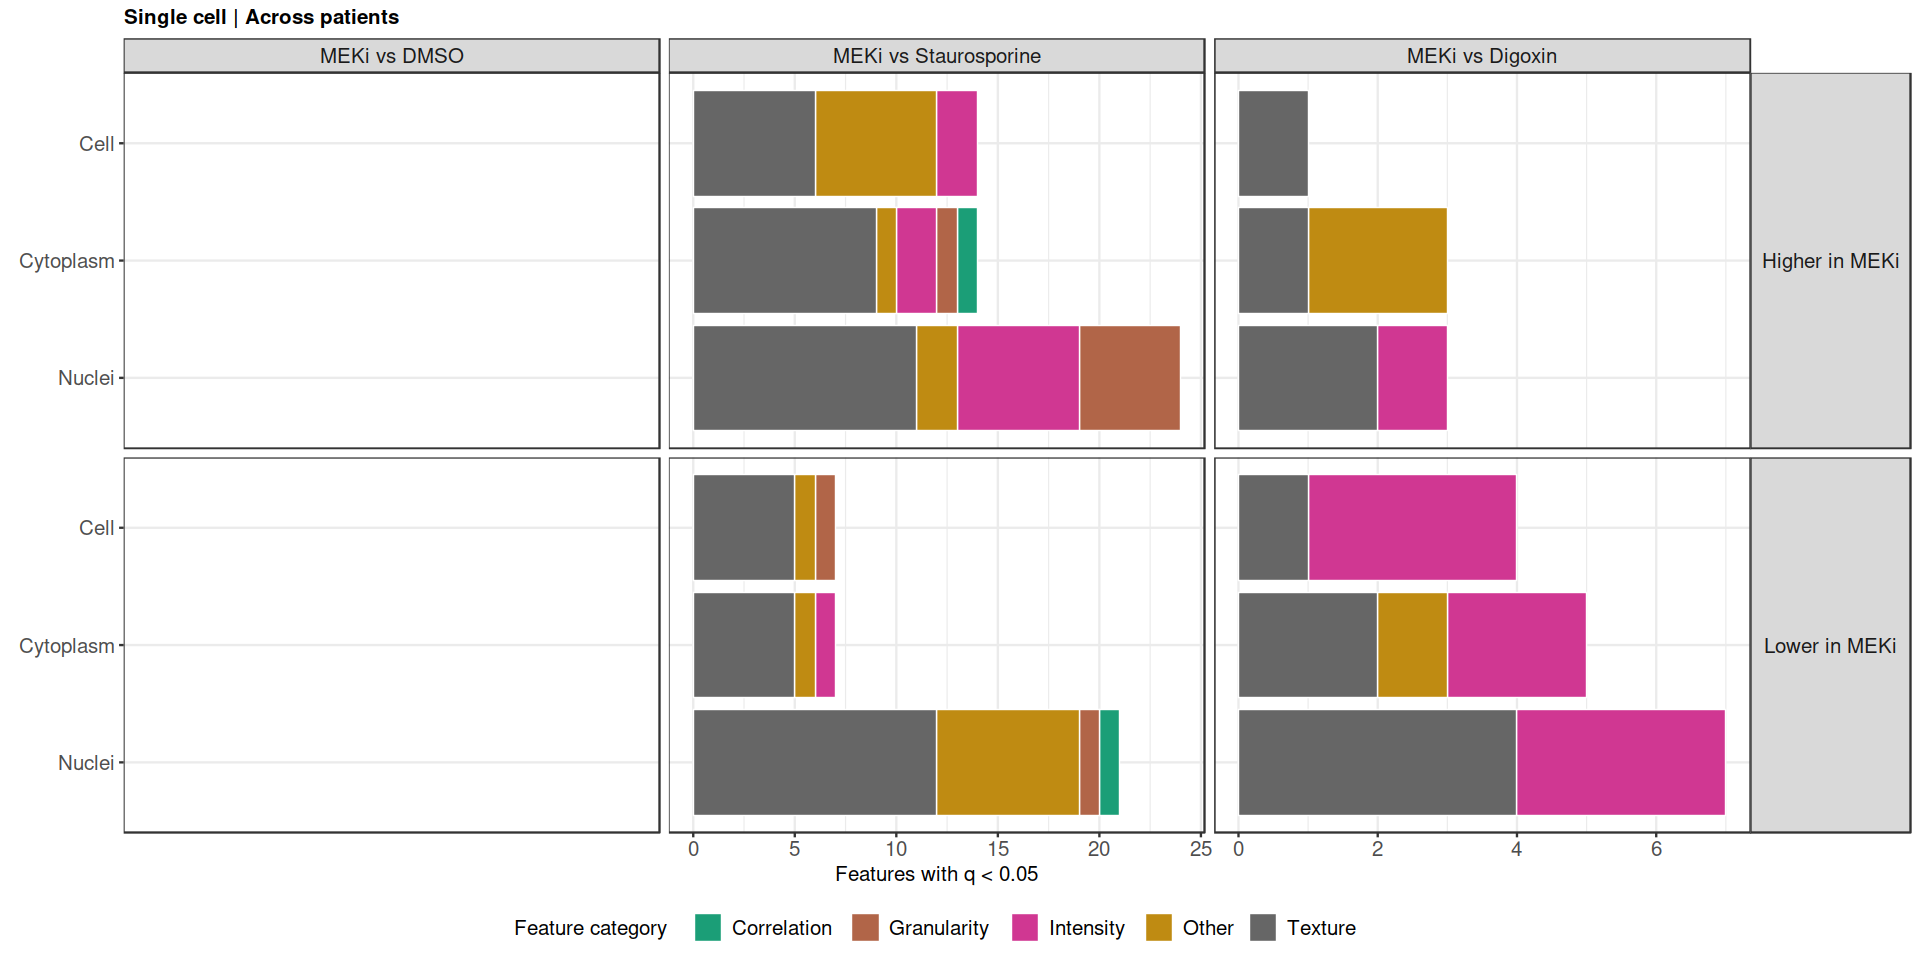

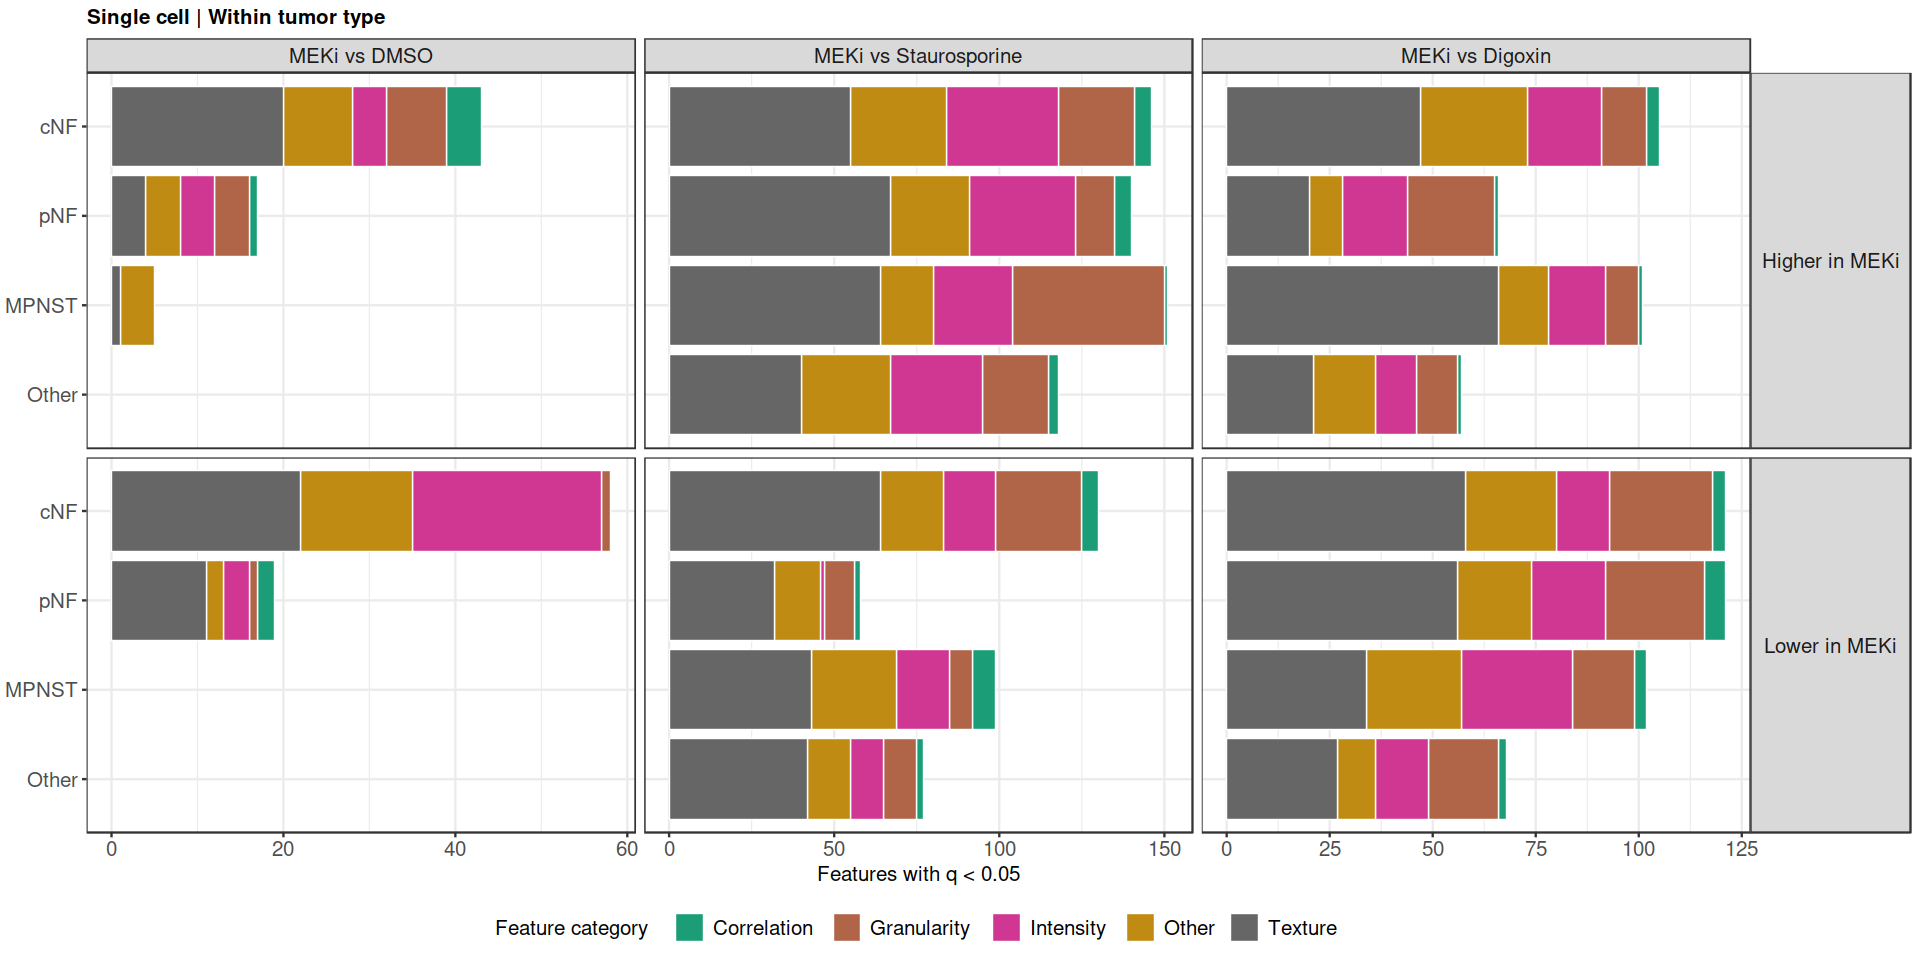

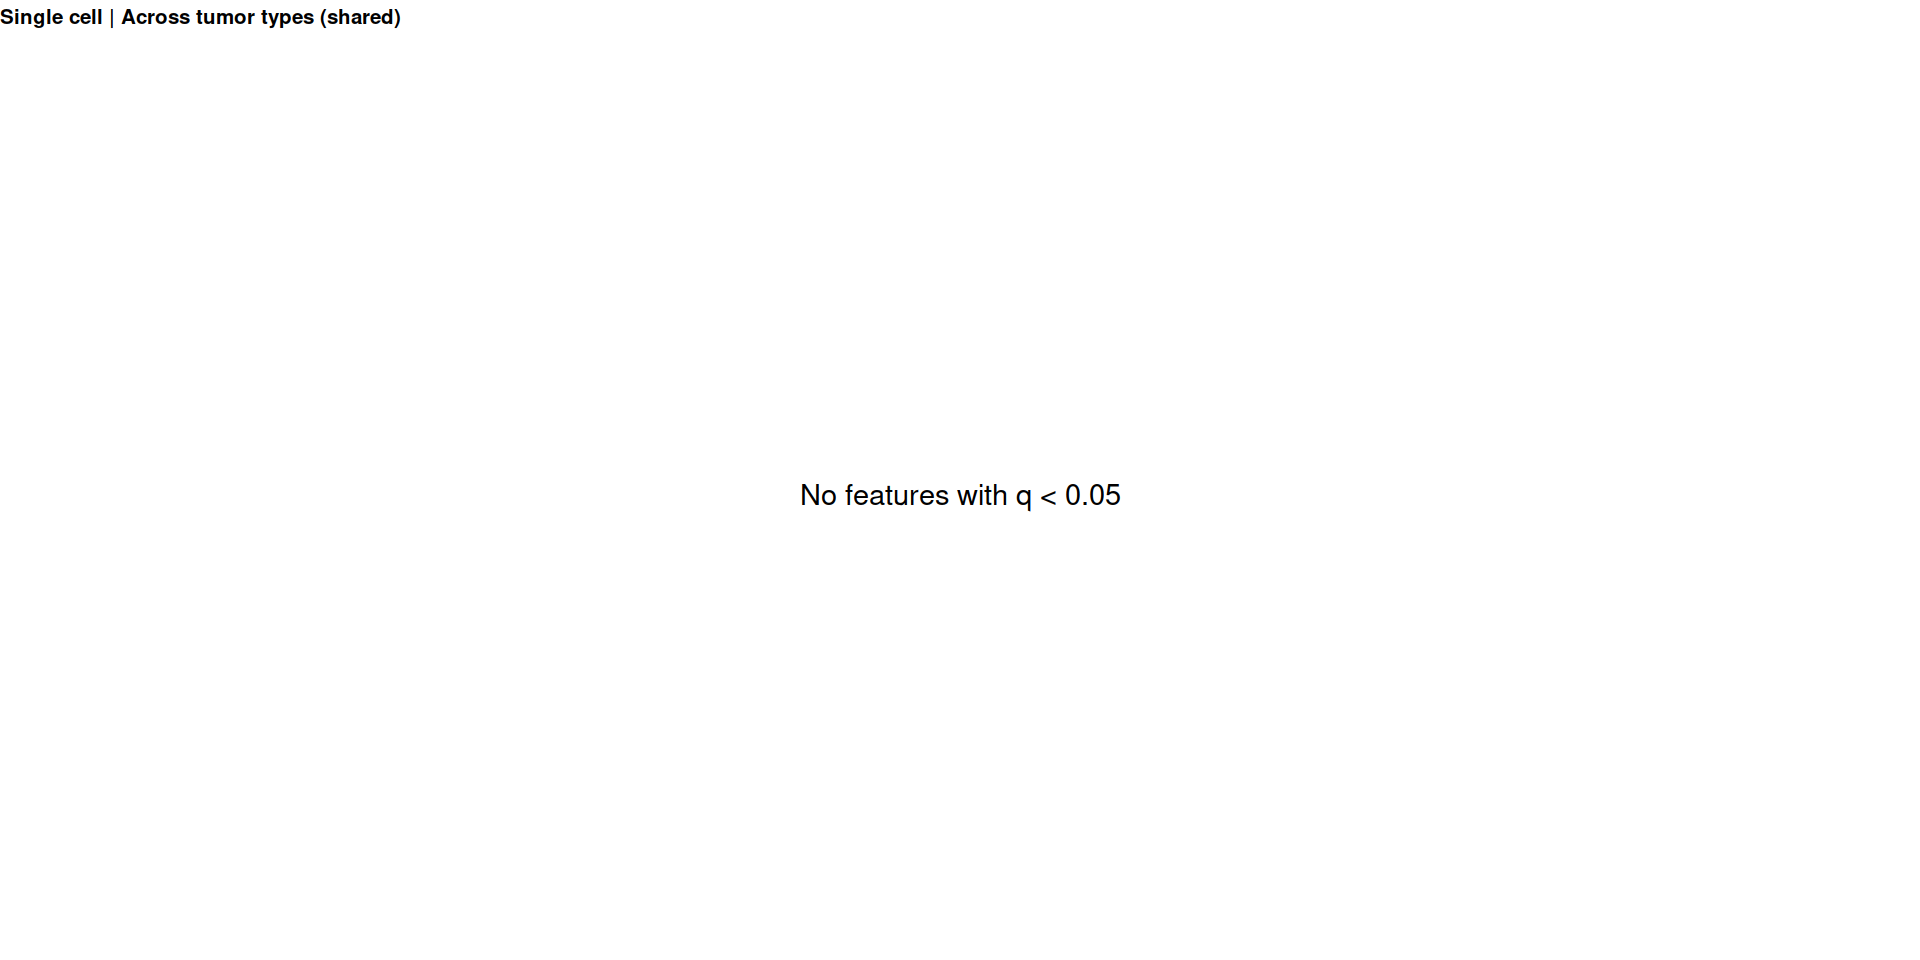

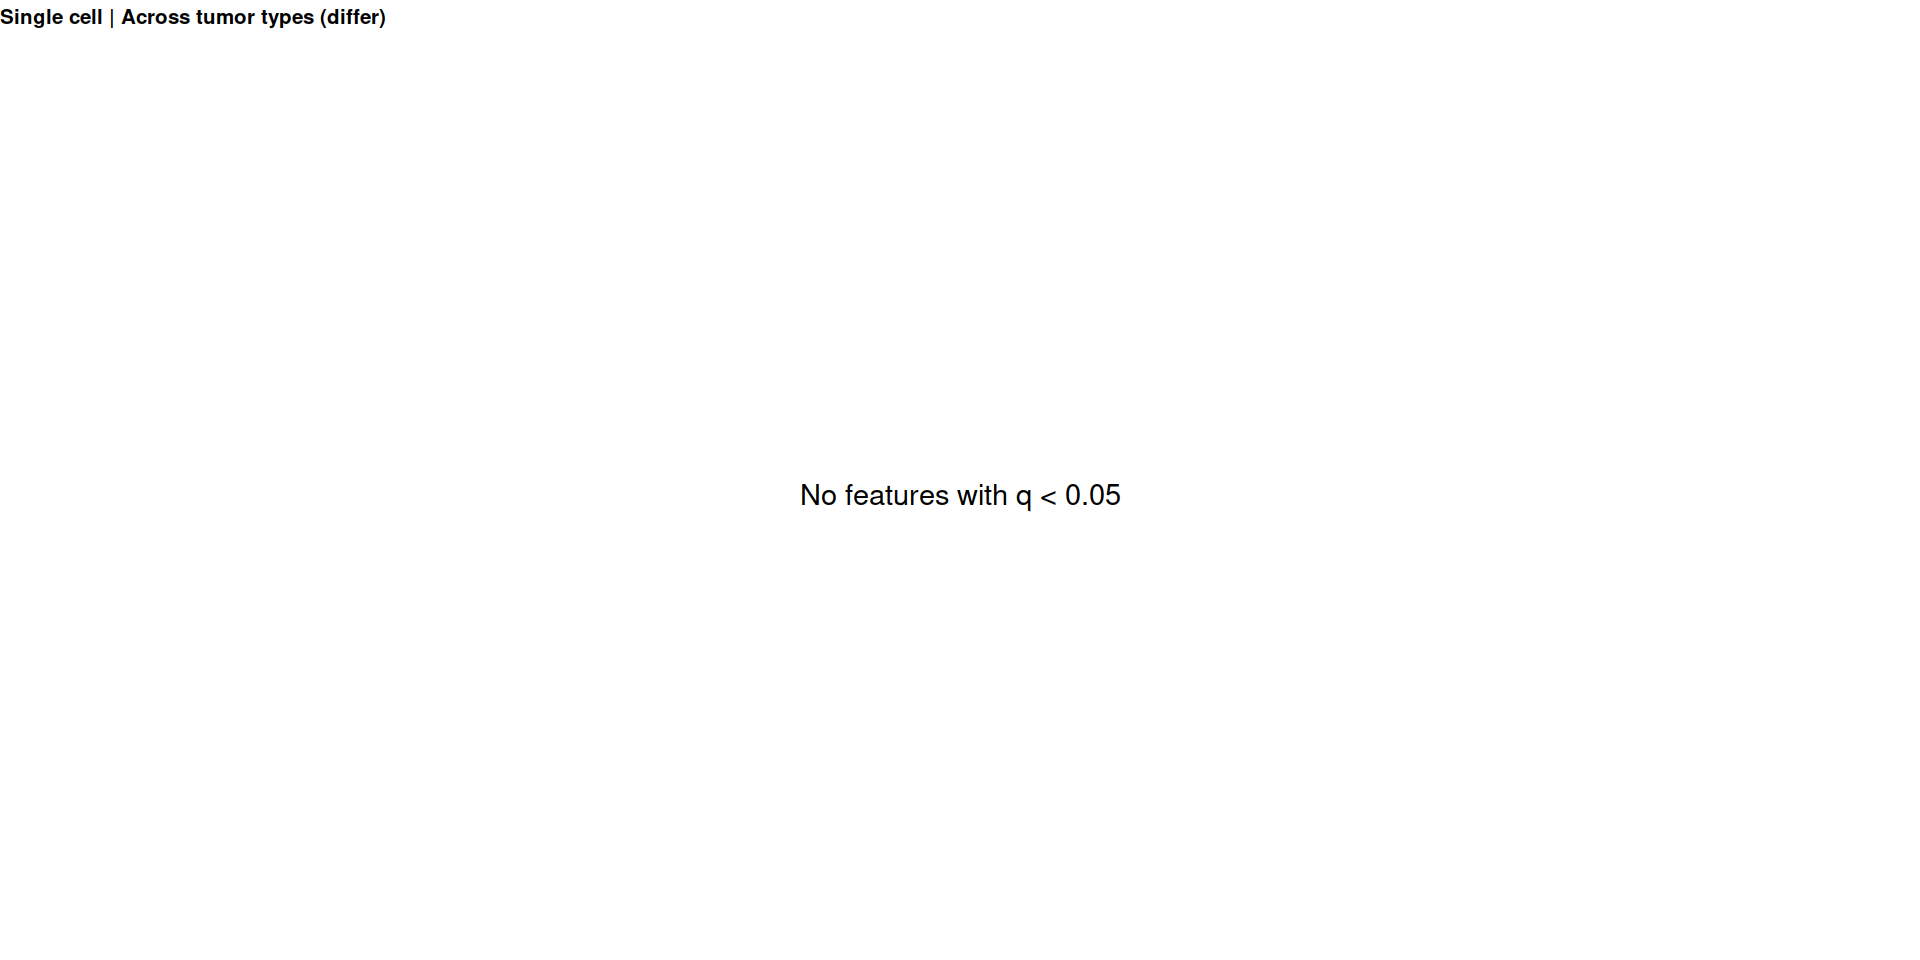

In [6]:
category_df <- level_test_df %>%
    filter(significant) %>%
    mutate(row_label = if_else(group == "all", feature_object, as.character(group_label))) %>%
    count(compartment, level, contrast, row_label, feature_category, direction)
# patients / tumor types in the same order as section 1, then feature objects
category_df$row_label <- factor(
    category_df$row_label,
    levels = union(levels(level_test_df$group_label), sort(unique(category_df$row_label)))
)

category_plot <- function(compartment_name, level_name) {
    plot_df <- category_df %>% filter(compartment == compartment_name, level == level_name)
    title <- paste0(compartment_name, " | ", level_name)
    if (nrow(plot_df) == 0) {
        return(
            ggplot()
            + annotate("text", x = 0, y = 0, label = paste0("No features with q < ", Q_THRESHOLD), size = 6)
            + labs(title = title)
            + theme_manuscript_void(base_size = 12)
        )
    }
    (
        ggplot(plot_df, aes(x = n, y = row_label, fill = feature_category))
        + geom_col(color = "white", linewidth = 0.3)
        + scale_y_discrete(limits = rev)
        + scale_fill_manual(values = category_palette)
        + facet_grid(direction ~ contrast, scales = "free_x", drop = FALSE)
        + labs(title = title, x = paste0("Features with q < ", Q_THRESHOLD), y = NULL, fill = "Feature category")
        + theme_manuscript(base_size = 12)
        + theme(strip.text.y = element_text(angle = 0), legend.position = "bottom")
    )
}

category_pages <- expand.grid(
    level = levels(level_test_df$level),
    compartment = levels(level_test_df$compartment),
    stringsAsFactors = FALSE
)
category_plots <- mapply(category_plot, category_pages$compartment, category_pages$level, SIMPLIFY = FALSE)
options(repr.plot.width = 16, repr.plot.height = 8)
save_plots_pdf(category_plots, category_path, width = 16, height = 8)
for (category_plot_page in category_plots) print(category_plot_page)

## 3. Recurrence of significant features across patients and tumor types
For each feature: the number of patients (or tumor types) in which it is significant on its own, colored by whether it is also significant when patients (or tumor type means) are pooled.
Features that are not significant in any patient / tumor type are left out.

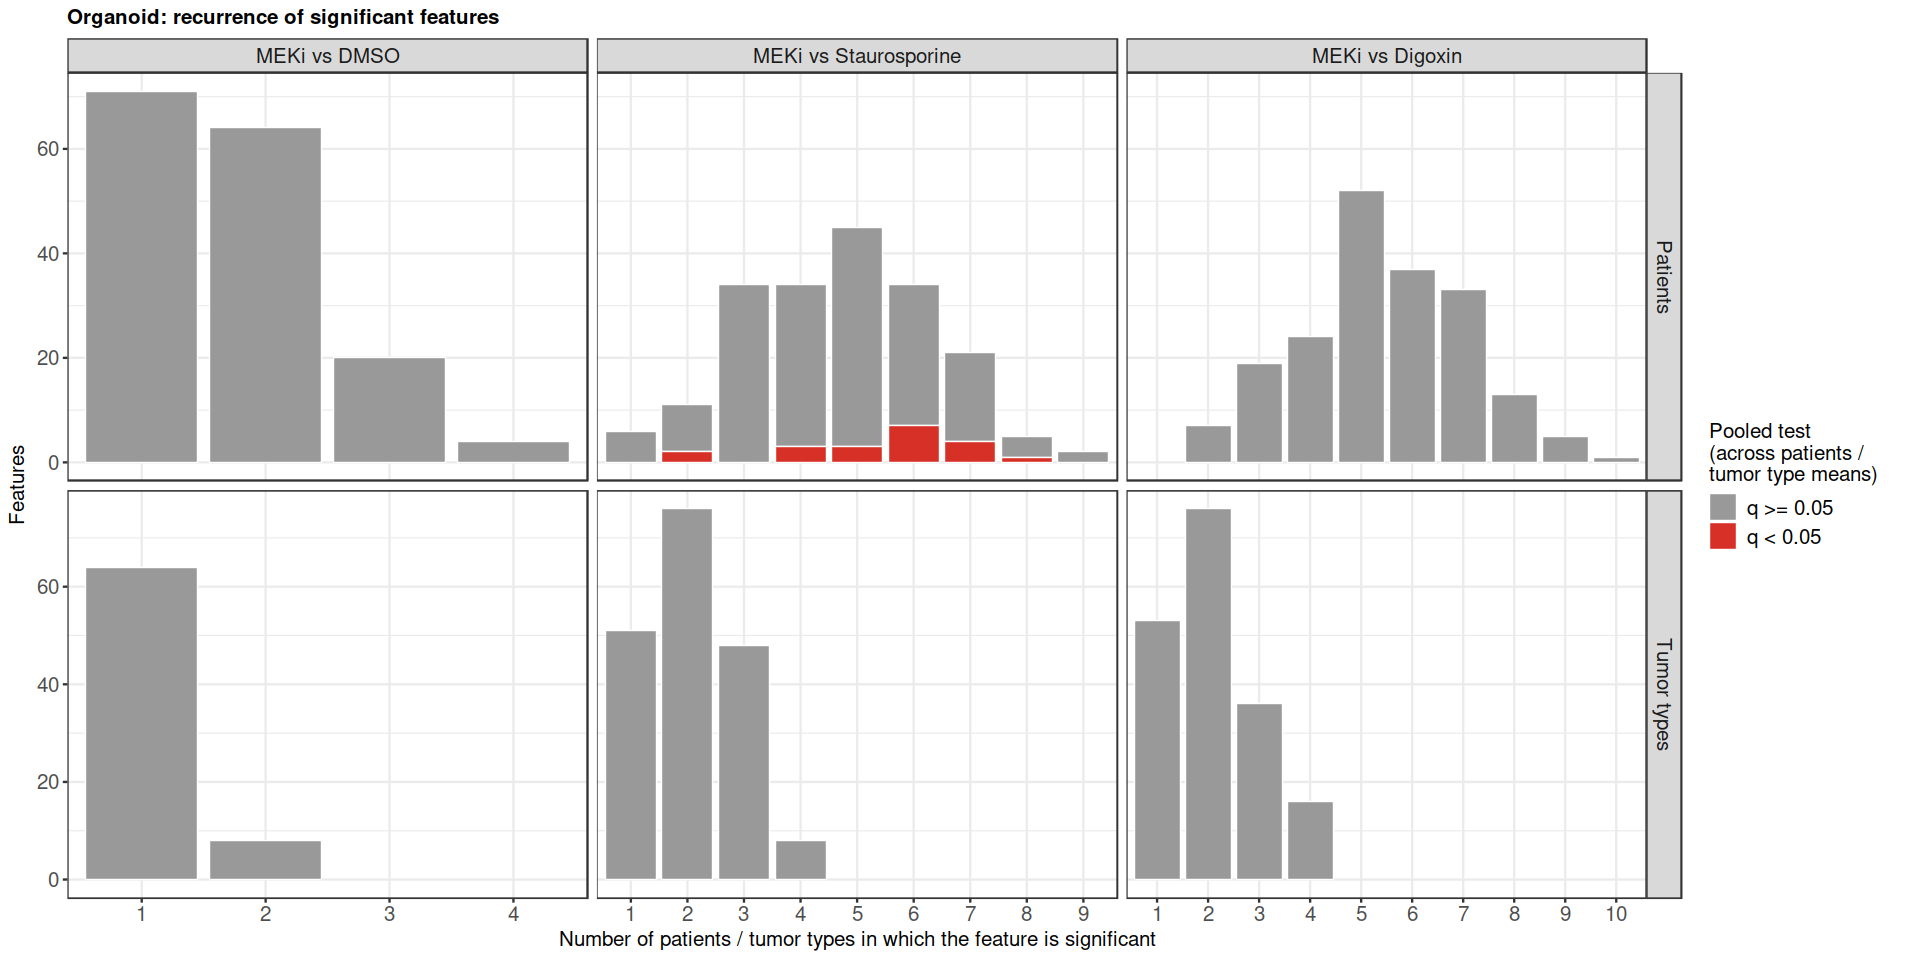

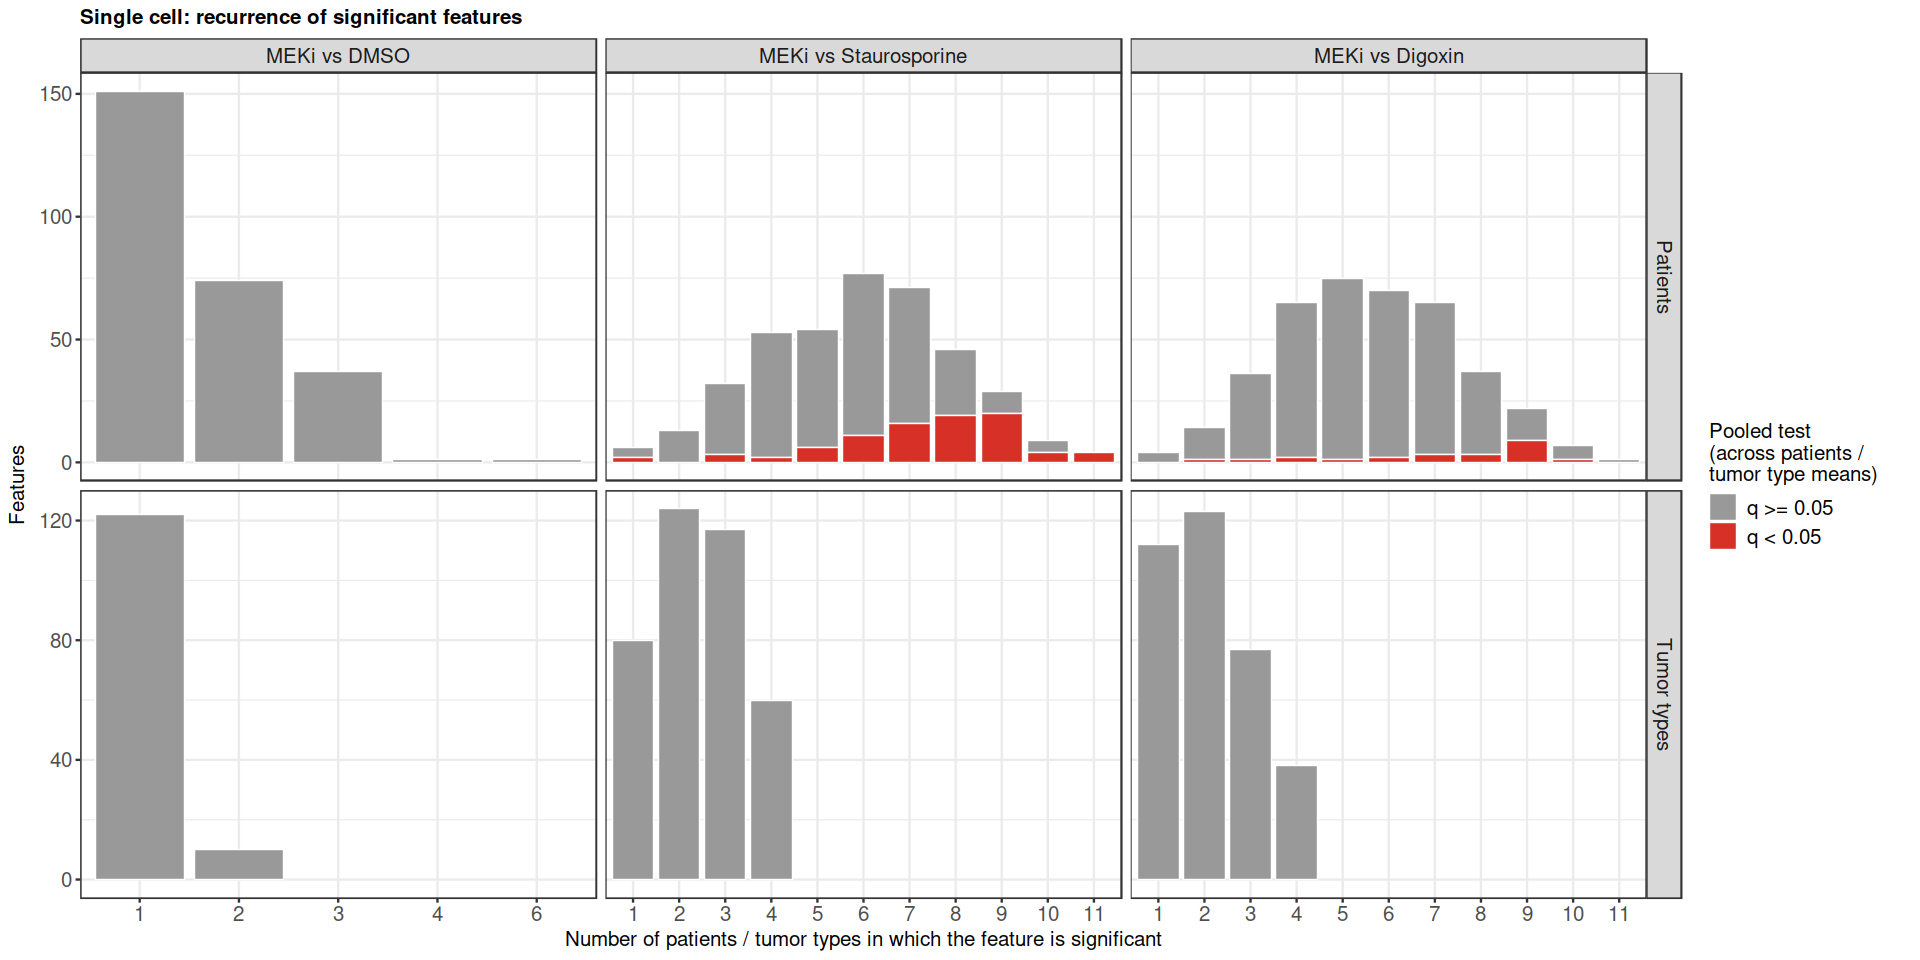

In [7]:
recurrence_df <- level_test_df %>%
    filter(level %in% level_labels[c("within_patient", "within_tumor_type")]) %>%
    group_by(compartment, contrast, feature, level) %>%
    summarise(n_groups_significant = sum(significant), .groups = "drop") %>%
    mutate(
        pooled_level = if_else(
            level == level_labels[["within_patient"]],
            level_labels[["across_patients"]],
            level_labels[["across_tumor_types_shared"]]
        ),
        unit = if_else(level == level_labels[["within_patient"]], "Patients", "Tumor types")
    ) %>%
    left_join(
        level_test_df %>%
            filter(group == "all") %>%
            select(compartment, contrast, feature, pooled_level = level, pooled_significant = significant) %>%
            mutate(pooled_level = as.character(pooled_level)),
        by = c("compartment", "contrast", "feature", "pooled_level")
    )

options(repr.plot.width = 16, repr.plot.height = 8)
recurrence_plots <- lapply(levels(recurrence_df$compartment), function(compartment_name) {
    (
        ggplot(
            recurrence_df %>% filter(compartment == compartment_name, n_groups_significant > 0),
            aes(x = factor(n_groups_significant), fill = pooled_significant)
        )
        + geom_bar(color = "white", linewidth = 0.3)
        + scale_fill_manual(
            values = c("FALSE" = "grey60", "TRUE" = "#d73027"),
            labels = c("FALSE" = paste0("q >= ", Q_THRESHOLD), "TRUE" = paste0("q < ", Q_THRESHOLD))
        )
        + facet_grid(unit ~ contrast, scales = "free", drop = FALSE)
        + labs(
            title = paste0(compartment_name, ": recurrence of significant features"),
            x = "Number of patients / tumor types in which the feature is significant",
            y = "Features",
            fill = "Pooled test\n(across patients /\ntumor type means)"
        )
        + theme_manuscript(base_size = 12)
    )
})
save_plots_pdf(recurrence_plots, recurrence_path, width = 16, height = 8)
for (recurrence_plot in recurrence_plots) print(recurrence_plot)

Features significant in the most patients per compartment x contrast, with how many tumor types they are significant in and the pooled across-patient result.

In [8]:
recurrence_df %>%
    select(compartment, contrast, feature, unit, n_groups_significant, pooled_significant) %>%
    pivot_wider(
        names_from = unit,
        values_from = c(n_groups_significant, pooled_significant)
    ) %>%
    group_by(compartment, contrast) %>%
    slice_max(n_groups_significant_Patients, n = 5, with_ties = FALSE) %>%
    ungroup() %>%
    select(
        compartment,
        contrast,
        feature,
        n_patients_significant = n_groups_significant_Patients,
        n_tumor_types_significant = `n_groups_significant_Tumor types`,
        significant_across_patients = pooled_significant_Patients,
        significant_across_tumor_types = `pooled_significant_Tumor types`
    )

compartment,contrast,feature,n_patients_significant,n_tumor_types_significant,significant_across_patients,significant_across_tumor_types
<fct>,<fct>,<chr>,<int>,<int>,<lgl>,<lgl>
Organoid,MEKi vs DMSO,Organoid_DNA-ER_Colocalization_RankWeightedColocalizationCoeff1,4,0,FALSE,FALSE
Organoid,MEKi vs DMSO,Organoid_DNA_Intensity_MeanAbsoluteDeviationIntensity,4,1,FALSE,FALSE
Organoid,MEKi vs DMSO,Organoid_ER_Granularity_10,4,1,FALSE,FALSE
Organoid,MEKi vs DMSO,Organoid_Mito_Intensity_MeanIntensity,4,1,FALSE,FALSE
Organoid,MEKi vs DMSO,Organoid_AGP-Mito_Colocalization_Correlation,3,1,FALSE,FALSE
Organoid,MEKi vs Staurosporine,Organoid_DNA-Mito_Colocalization_Correlation,9,4,FALSE,FALSE
Organoid,MEKi vs Staurosporine,Organoid_DNA-Mito_Colocalization_MandersCoeffM2,9,2,FALSE,FALSE
Organoid,MEKi vs Staurosporine,Organoid_DNA-Mito_Colocalization_MandersCoeffCostesM1,8,3,FALSE,FALSE
Organoid,MEKi vs Staurosporine,Organoid_ER-Mito_Colocalization_MandersCoeffCostesM1,8,4,FALSE,FALSE
